# Распределение расстояний от случайного выбранного объекта до всех остальных из датасета

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import random
import torch


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")


set_seed()

Random seed set as 42


In [ ]:
import torch
# import torchsde
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 140


from tqdm.notebook import tqdm
from torchvision import transforms
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import euclidean_distances
# from torchdyn.core import NeuralODE
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error


# from torchcfm.conditional_flow_matching import *
# from torchcfm.models.unet import UNetModel

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
data_path = '/content/drive/MyDrive/cursach-hse'

In [ ]:
!unzip {data_path}/mnist_data/train.csv.zip

Archive:  /content/drive/MyDrive/cursach-hse/mnist_data/train.csv.zip
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


### Получить все эмбеддинги

Нужно лишь один раз, далее запускать НЕ НАДО

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)


class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.gelu(self.linear1(z))
        z = torch.tanh(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))


class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
class CustomMnistDataset(torch.utils.data.Dataset):
    """
    Reads the MNIST data from csv file given file path.
    """
    def __init__(self, csv_path, num_datapoints = None):
        super(CustomMnistDataset, self).__init__()

        self.df = pd.read_csv(csv_path)

        # Will be useful later while evaluating
        if num_datapoints is not None:
            self.df = self.df.iloc[0:num_datapoints]

    def __len__(self):
        return len(self.df)

    def  __getitem__(self, index):
        # Read
        img = self.df.iloc[index].filter(regex='pixel').values
        img =  np.reshape(img, (28, 28)).astype(np.uint8)

        # Convert to Tensor
        img_tensor = transforms.ToTensor()(img) # [0, 1]
        # img_tensor = 2*img_tensor - 1 # [-1, 1]
        img_tensor = transforms.Normalize((0.5,), (0.5,))(img_tensor)

        return img_tensor

In [ ]:
train_csv_path = '/content/train.csv'
batch_size = 6000

trainset = CustomMnistDataset(train_csv_path)
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=False, drop_last=False
)

In [ ]:
ae = Autoencoder(100).to(device)
ae.load_state_dict(torch.load(os.path.join(data_path, 'compare_two_unseen', 'ae_100dim_new.pth'), weights_only=True))
ae.eval()

Autoencoder(
  (encoder): Encoder(
    (linear1): Linear(in_features=784, out_features=512, bias=True)
    (linear2): Linear(in_features=512, out_features=100, bias=True)
  )
  (decoder): Decoder(
    (linear1): Linear(in_features=100, out_features=512, bias=True)
    (linear2): Linear(in_features=512, out_features=784, bias=True)
  )
)

In [ ]:
orig_embds = []

for data in tqdm(train_loader):
    data = data.to(device)
    embds = ae.encoder(data)
    orig_embds.append(embds.to('cpu').detach().numpy())

  0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
orig_embds = np.vstack(orig_embds)
orig_embds.shape

(42000, 100)

In [ ]:
cfm_fake_imgs = np.load(os.path.join(data_path, 'compare_two_unseen', 'cfm_imgs_3000_newnew.npy'))
ddim_fake_imgs = np.load(os.path.join(data_path, 'ddim_imgs_3072.npy'))

cfm_fake_imgs = torch.Tensor(cfm_fake_imgs).view(3000, 28, 28)
cfm_fake_imgs = cfm_fake_imgs.to(device)

ddim_fake_imgs = torch.Tensor(ddim_fake_imgs).view(3072, 28, 28)
ddim_fake_imgs = ddim_fake_imgs.to(device)

cfm_fake_embds = ae.encoder(cfm_fake_imgs)
ddim_fake_embds = ae.encoder(ddim_fake_imgs)

In [ ]:
cfm_fake_embds = cfm_fake_embds.detach().cpu().numpy()
ddim_fake_embds = ddim_fake_embds.detach().cpu().numpy()

In [ ]:
np.save('cfm_fake_embds.npy', cfm_fake_embds)
np.save('ddim_fake_embds.npy', ddim_fake_embds)

In [ ]:
cfm_fake_embds.shape, ddim_fake_embds.shape

((3000, 100), (3072, 100))

In [ ]:
ddim_fake_imgs_all = np.load(os.path.join(data_path, 'ddim_imgs_42000.npy'))
ddim_fake_imgs_all = torch.Tensor(ddim_fake_imgs_all).view(42000, 28, 28).to(device)
ddim_fake_embds_all = ae.encoder(ddim_fake_imgs_all)

In [ ]:
ddim_fake_embds_all.shape

torch.Size([42000, 100])

In [ ]:
ddim_fake_embds_all = ddim_fake_embds_all.detach().cpu().numpy()

In [ ]:
np.save('ddim_fake_embds_42000.npy', ddim_fake_embds_all)

### Гистограммы расстояний

Тут эмбеддинги уже предпосчитали

In [ ]:
orig_embds = np.load(os.path.join(data_path, 'distances_distribution', 'train_embds_42000.npy'))
orig_embds.shape

(42000, 100)

In [ ]:
mnist_df = pd.read_csv('train.csv')

In [ ]:
mnist_df.label.value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [ ]:
idxs_0 = mnist_df.index[mnist_df['label'] == 0].tolist()

In [ ]:
idxs_0[:10]

[1, 4, 5, 17, 23, 54, 63, 69, 98, 108]

In [ ]:
!mkdir /content/Images

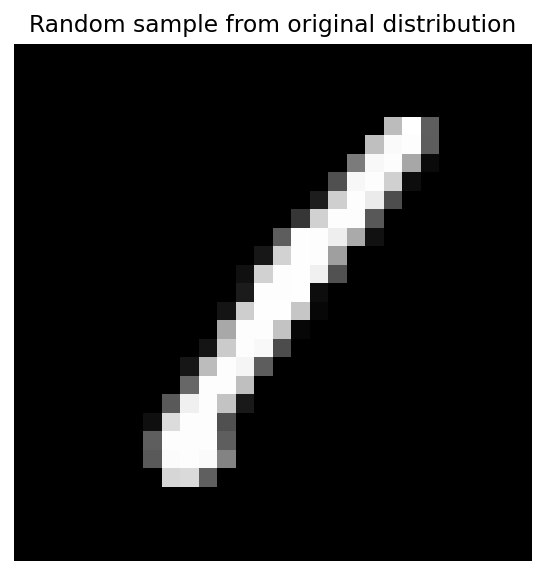

In [ ]:
random_idx = 0
random_image = mnist_df.iloc[random_idx].filter(regex='pixel').values
random_image = np.reshape(random_image, (28, 28)).astype(np.uint8)

fig1 = plt.gcf()
plt.imshow(random_image, cmap='gray')
plt.axis('off')
plt.title('Random sample from original distribution')
fig1.savefig('/content/Images/random_sample_distance.png')

In [ ]:
all_distances = euclidean_distances(orig_embds, orig_embds)
all_distances.shape

(42000, 42000)

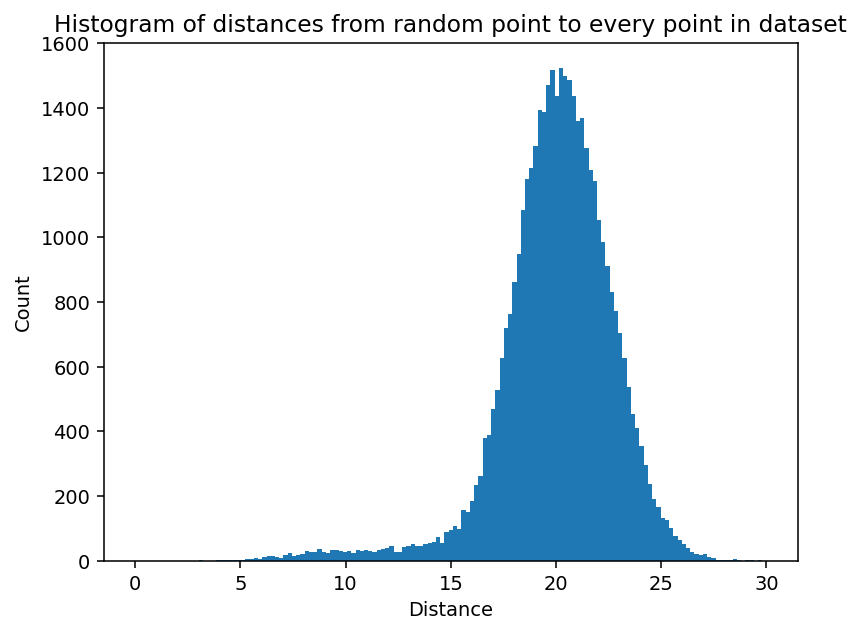

In [ ]:
fig1 = plt.gcf()
counts, bins, bars = plt.hist(np.delete(all_distances[random_idx], random_idx), bins=np.linspace(0, 30, 150))
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Histogram of distances from random point to every point in dataset')
fig1.savefig('/content/Images/histogram_random.png')

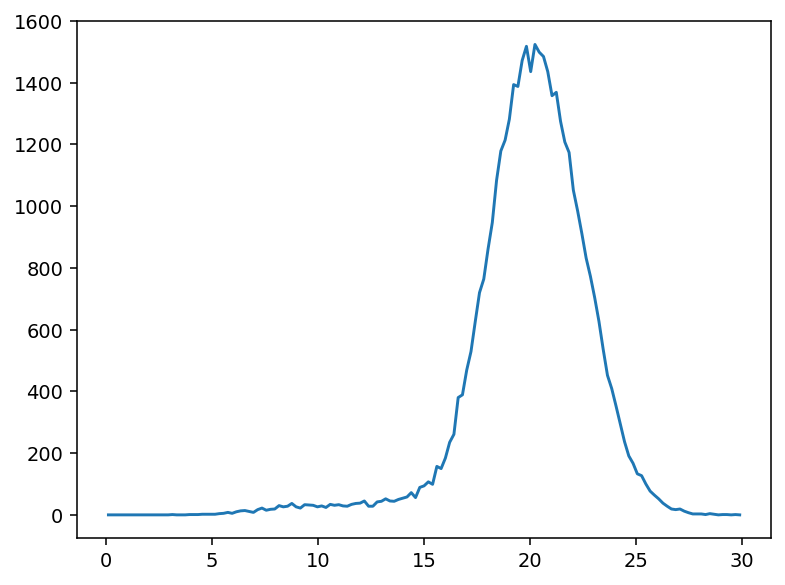

In [ ]:
X = np.array([0.5 * (bins[i] + bins[i+1]) for i in range(len(bins) - 1)])
plt.plot(X, counts)

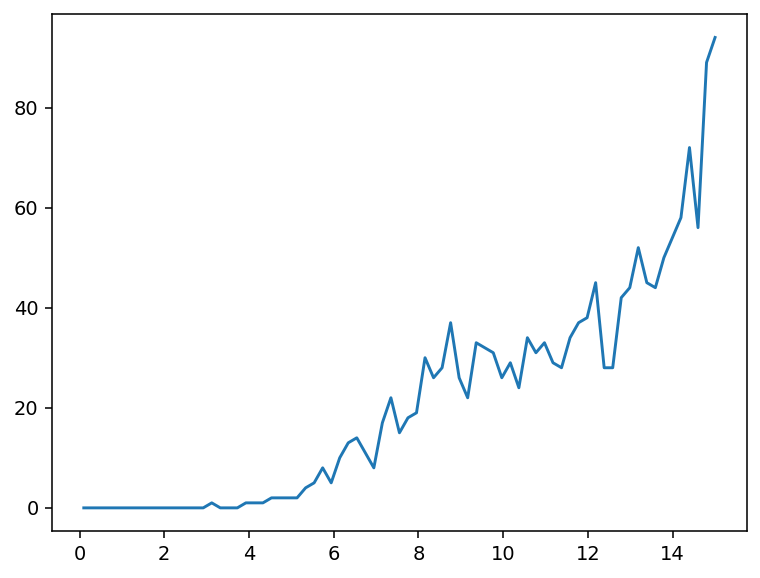

In [ ]:
# plt.plot(X[:150], counts[:150], 'o', markersize=2)
plt.plot(X[:75], counts[:75])

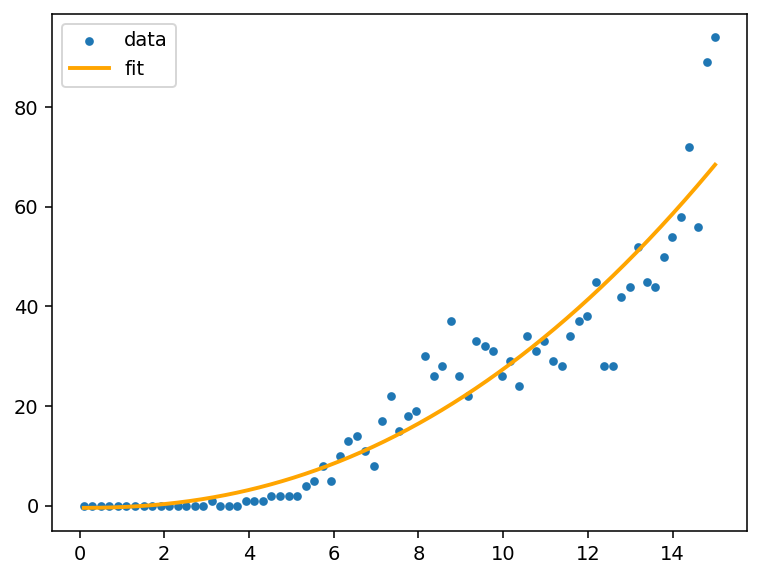

In [ ]:
from scipy.optimize import curve_fit

def model(x, a, b, c):
    return a * np.power(x, b) + c

p0 = (1.0, 0.1, 0.0)

params, cov = curve_fit(model, X[:75], counts[:75], p0=p0, maxfev=10000)

xg = np.linspace(X[:75].min(), X[:75].max(), 1000)
yg = model(xg, *params)

plt.scatter(X[:75], counts[:75], s=12, label='data')
plt.plot(xg, yg, linewidth=2, label=f'fit', c='orange')
plt.legend()
plt.show()

In [ ]:
params

array([ 0.16297471,  2.23280618, -0.4265593 ])

In [ ]:
from sklearn.metrics import mean_squared_error

Y_pred = model(X[:75], *params)

rmse = np.sqrt(mean_squared_error(counts[:75], Y_pred))
rmse

np.float64(6.786930805800467)

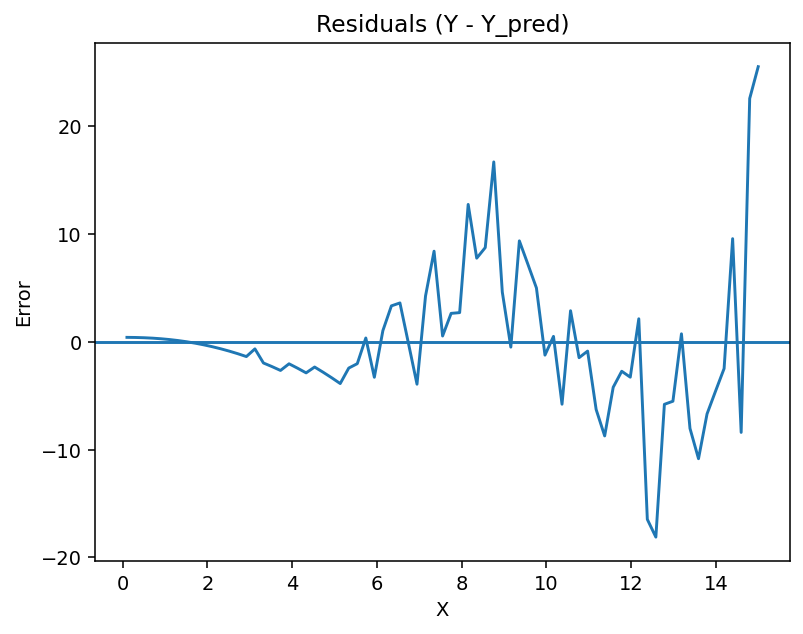

In [ ]:
residuals = counts[:75] - Y_pred

plt.figure()
plt.plot(X[:75], residuals)
plt.axhline(0)
plt.title("Residuals (Y - Y_pred)")
plt.xlabel("X")
plt.ylabel("Error")
plt.show()

RMSE: 2.1743556302740705


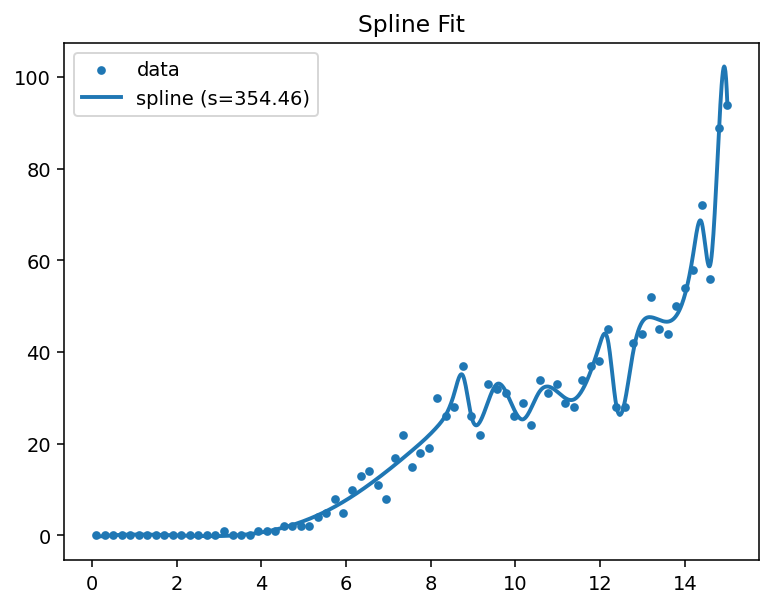

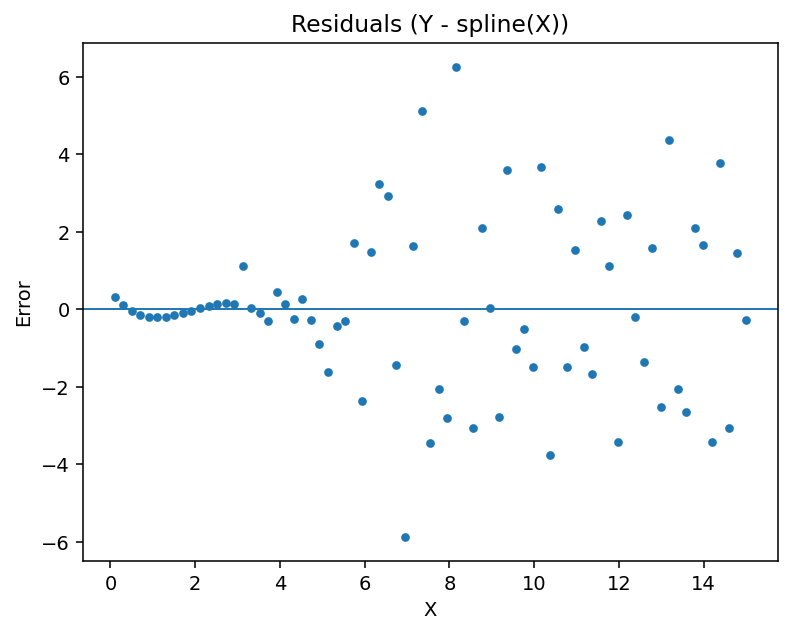

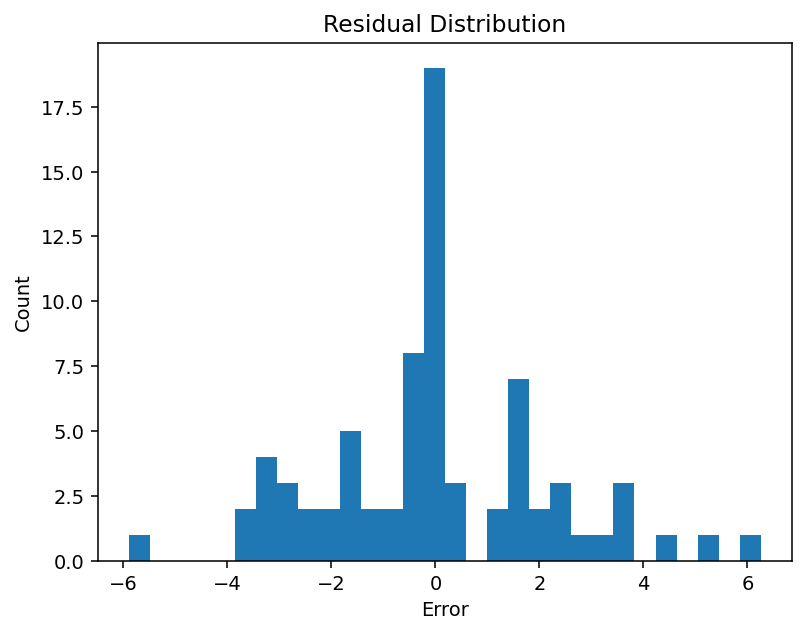

In [ ]:
from scipy.interpolate import UnivariateSpline

idx = np.argsort(X[:75])
xs = X[idx]
ys = counts[idx]

s = len(X[:75]) * np.var(counts[:75]) * 1e-2
spl = UnivariateSpline(xs, ys, s=s)

Y_pred = spl(X[:75])

rmse = np.sqrt(np.mean((counts[:75] - Y_pred) ** 2))
print("RMSE:", rmse)

residuals = counts[:75] - Y_pred

xg = np.linspace(xs.min(), xs.max(), 1000)
yg = spl(xg)

plt.figure()
plt.scatter(X[:75], counts[:75], s=12, label="data")
plt.plot(xg, yg, linewidth=2, label=f"spline (s={s})")
plt.title("Spline Fit")
plt.legend()
plt.show()

plt.figure()
plt.scatter(X[:75], residuals, s=12)
plt.axhline(0, linewidth=1)
plt.title("Residuals (Y - spline(X))")
plt.xlabel("X")
plt.ylabel("Error")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()


In [ ]:
from scipy.optimize import curve_fit


def func(x, a, b, c):
    return a * np.power(x, b) + c


# these are the same as the scipy defaults
initialParameters = np.array([1.0, 1.0, 1.0])

# curve fit the test data
fittedParameters, pcov = curve_fit(func, X[:200], counts[:200], initialParameters)

modelPredictions = func(X[:200], *fittedParameters)

absError = modelPredictions - counts[:200]

SE = np.square(absError) # squared errors
MSE = np.mean(SE) # mean squared errors
RMSE = np.sqrt(MSE) # Root Mean Squared Error, RMSE
Rsquared = 1.0 - (np.var(absError) / np.var(counts[:200]))

print('Parameters:', fittedParameters)
print('RMSE:', RMSE)
print('R-squared:', Rsquared)

print()

Parameters: [ 4.15341132e-08  7.93548819e+00 -1.08933685e+00]
RMSE: 31.325856799686917
R-squared: 0.9747293945226906



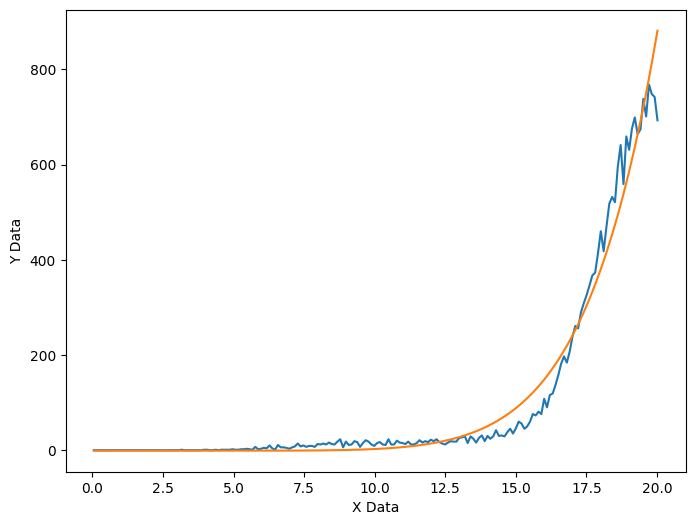

In [ ]:
def ModelAndScatterPlot(graphWidth, graphHeight):
    f = plt.figure(figsize=(graphWidth/100.0, graphHeight/100.0), dpi=100)
    axes = f.add_subplot(111)

    axes.plot(X[:200], counts[:200])

    xModel = X[:200]
    yModel = func(xModel, *fittedParameters)

    axes.plot(xModel, yModel)

    axes.set_xlabel('X Data')
    axes.set_ylabel('Y Data')

    # plt.xscale('log')


    plt.show()

graphWidth = 800
graphHeight = 600
ModelAndScatterPlot(graphWidth, graphHeight)

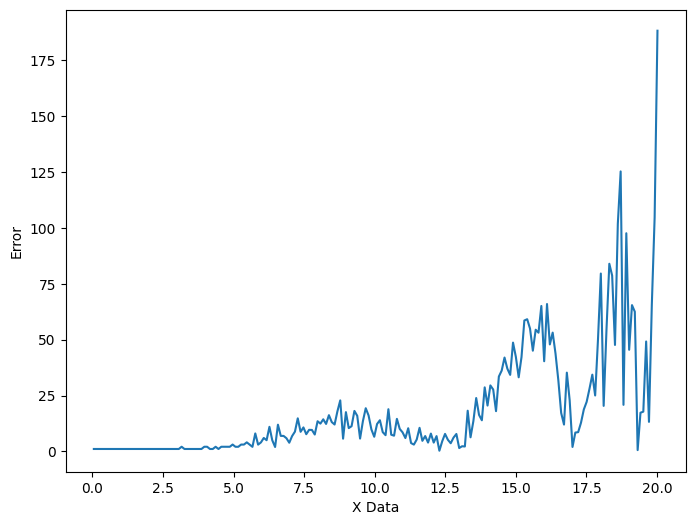

In [ ]:
def PlotErrors(graphWidth, graphHeight):
    f = plt.figure(figsize=(graphWidth/100.0, graphHeight/100.0), dpi=100)
    axes = f.add_subplot(111)

    xModel = X[:200]
    yModel = func(xModel, *fittedParameters)

    errs = np.abs(yModel - counts[:200])

    axes.plot(xModel, errs)

    axes.set_xlabel('X Data')
    axes.set_ylabel('Error')

    # plt.xscale('log')


    plt.show()

graphWidth = 800
graphHeight = 600
PlotErrors(graphWidth, graphHeight)

## Гистограммы по всему датасету

In [ ]:
def plot_histograms(distances, label, df):
    fig, axes = plt.subplots(10, 2, figsize=(9, 16))
    idxs_label = df.index[df['label'] == label].tolist()

    for i in range(10):
        idx = idxs_label[i]
        image = df.iloc[idx].filter(regex='pixel').values
        image = np.reshape(image, (28, 28)).astype(np.uint8)
        dist = np.delete(distances[idx], idx)

        axes[i, 0].imshow(image, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 1].hist(dist, bins=np.linspace(0, 30, 300))
        # axes[i, 1].hist(dist, bins='auto')

    plt.tight_layout()
    plt.show()


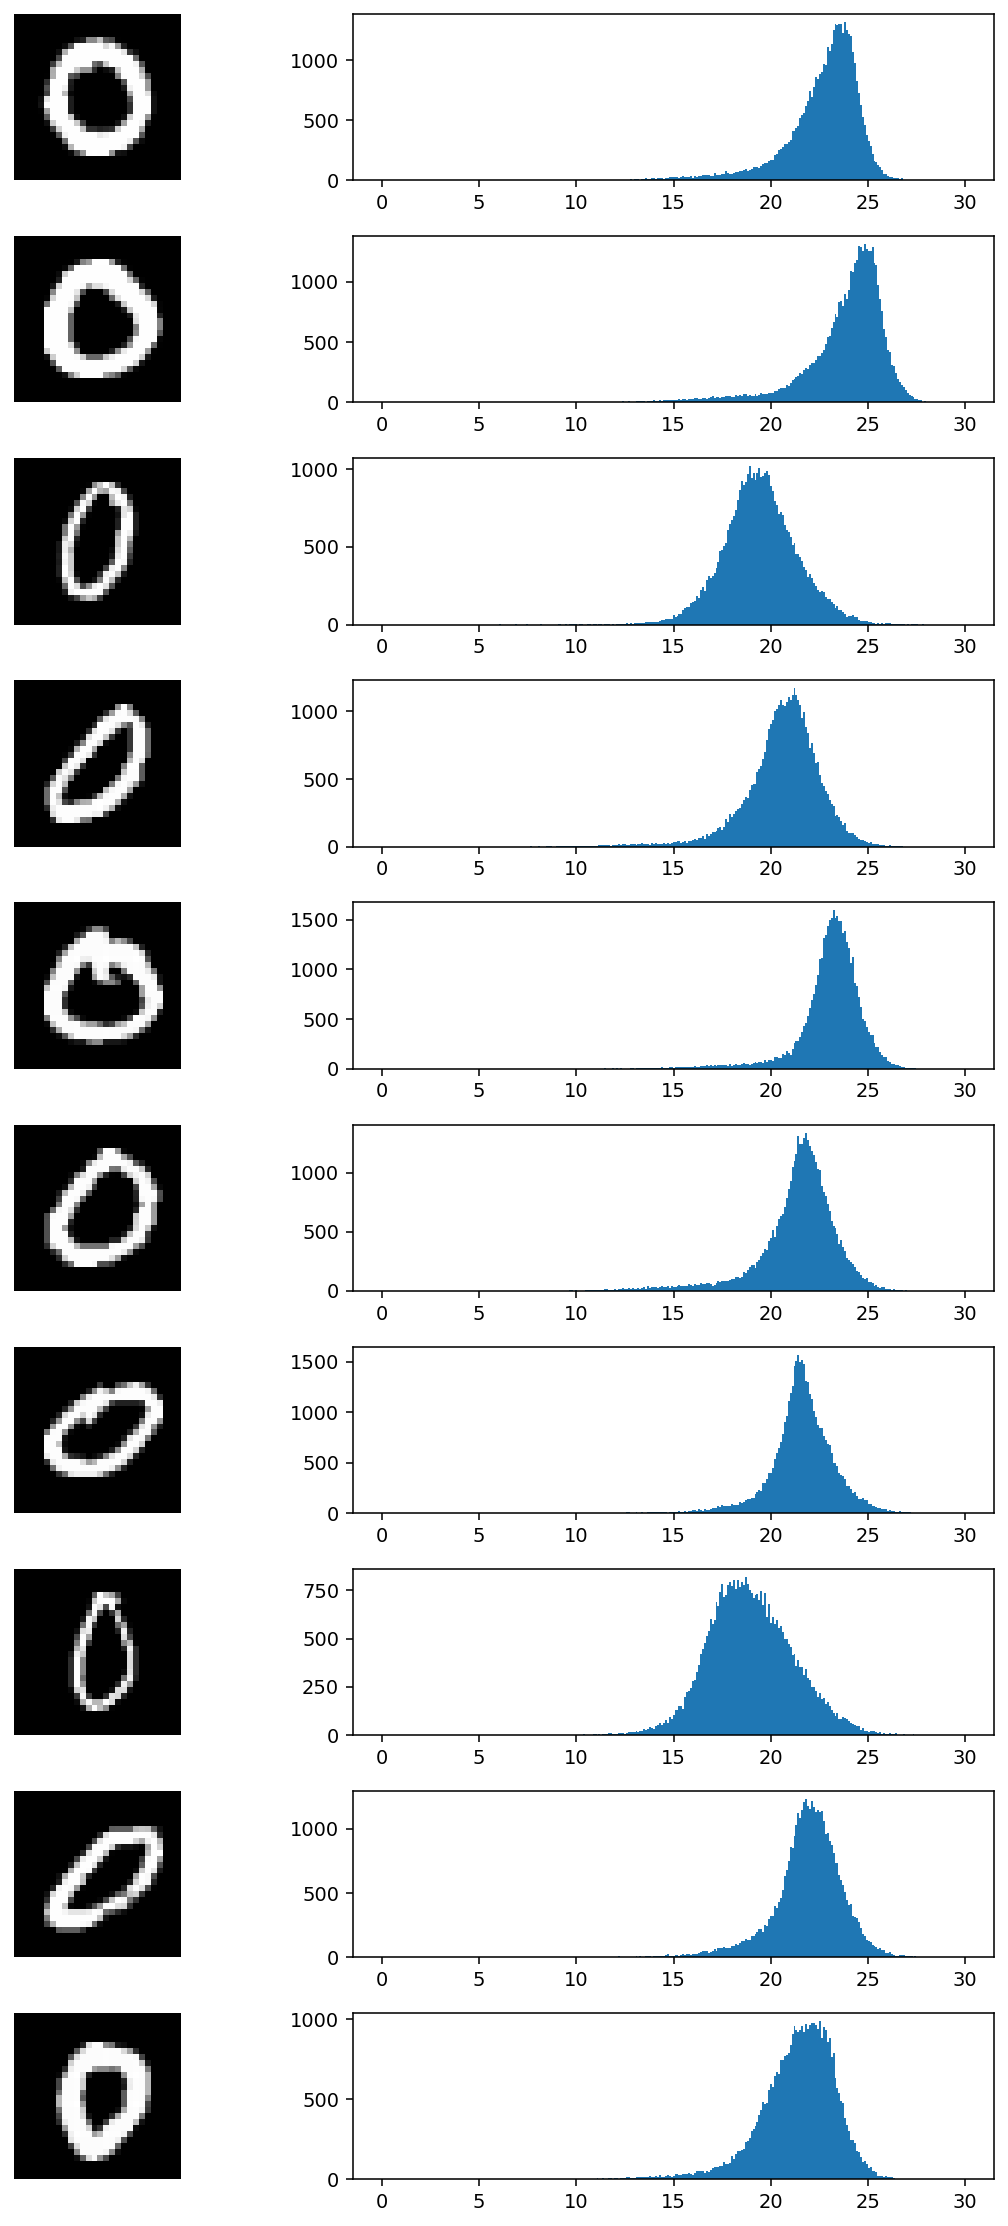

In [ ]:
plot_histograms(all_distances, 0, mnist_df)

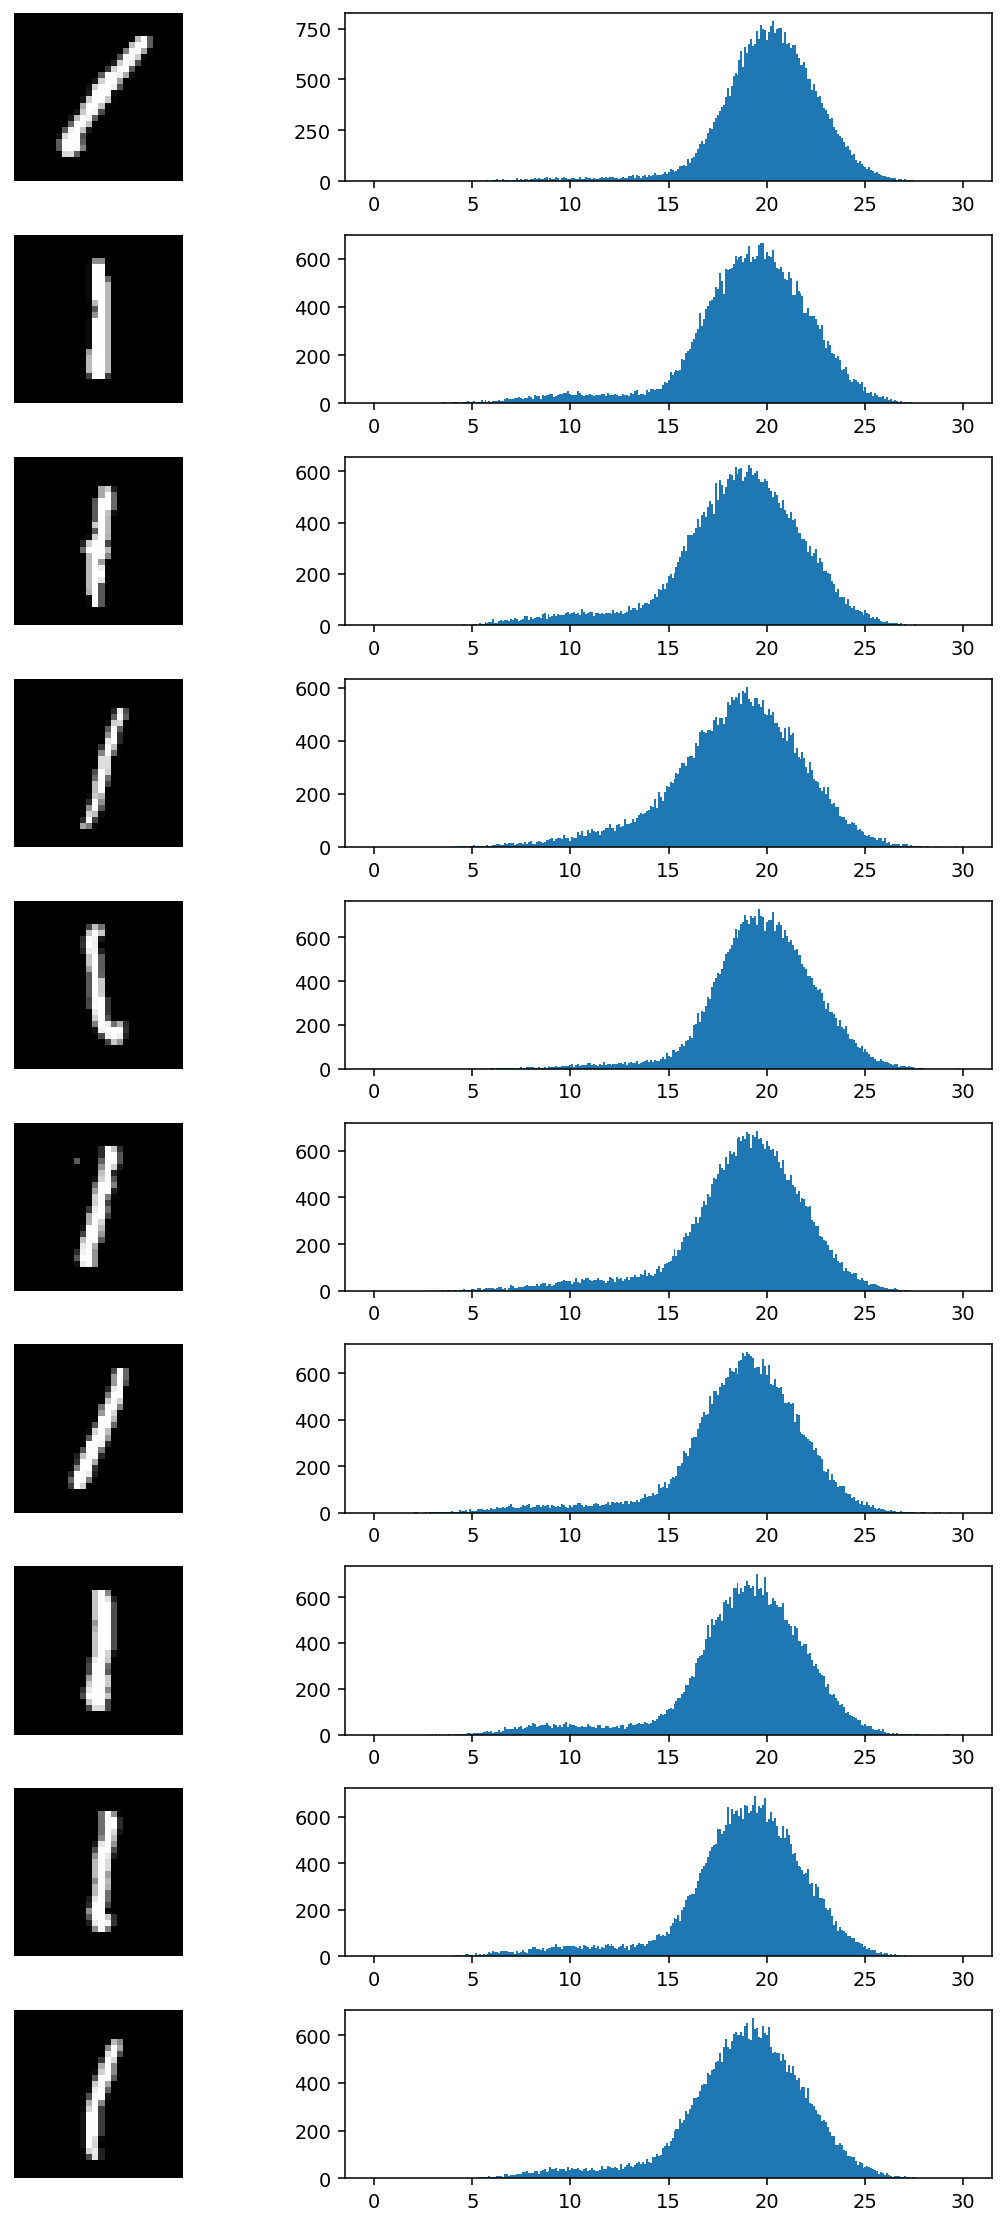

In [ ]:
plot_histograms(all_distances, 1, mnist_df)

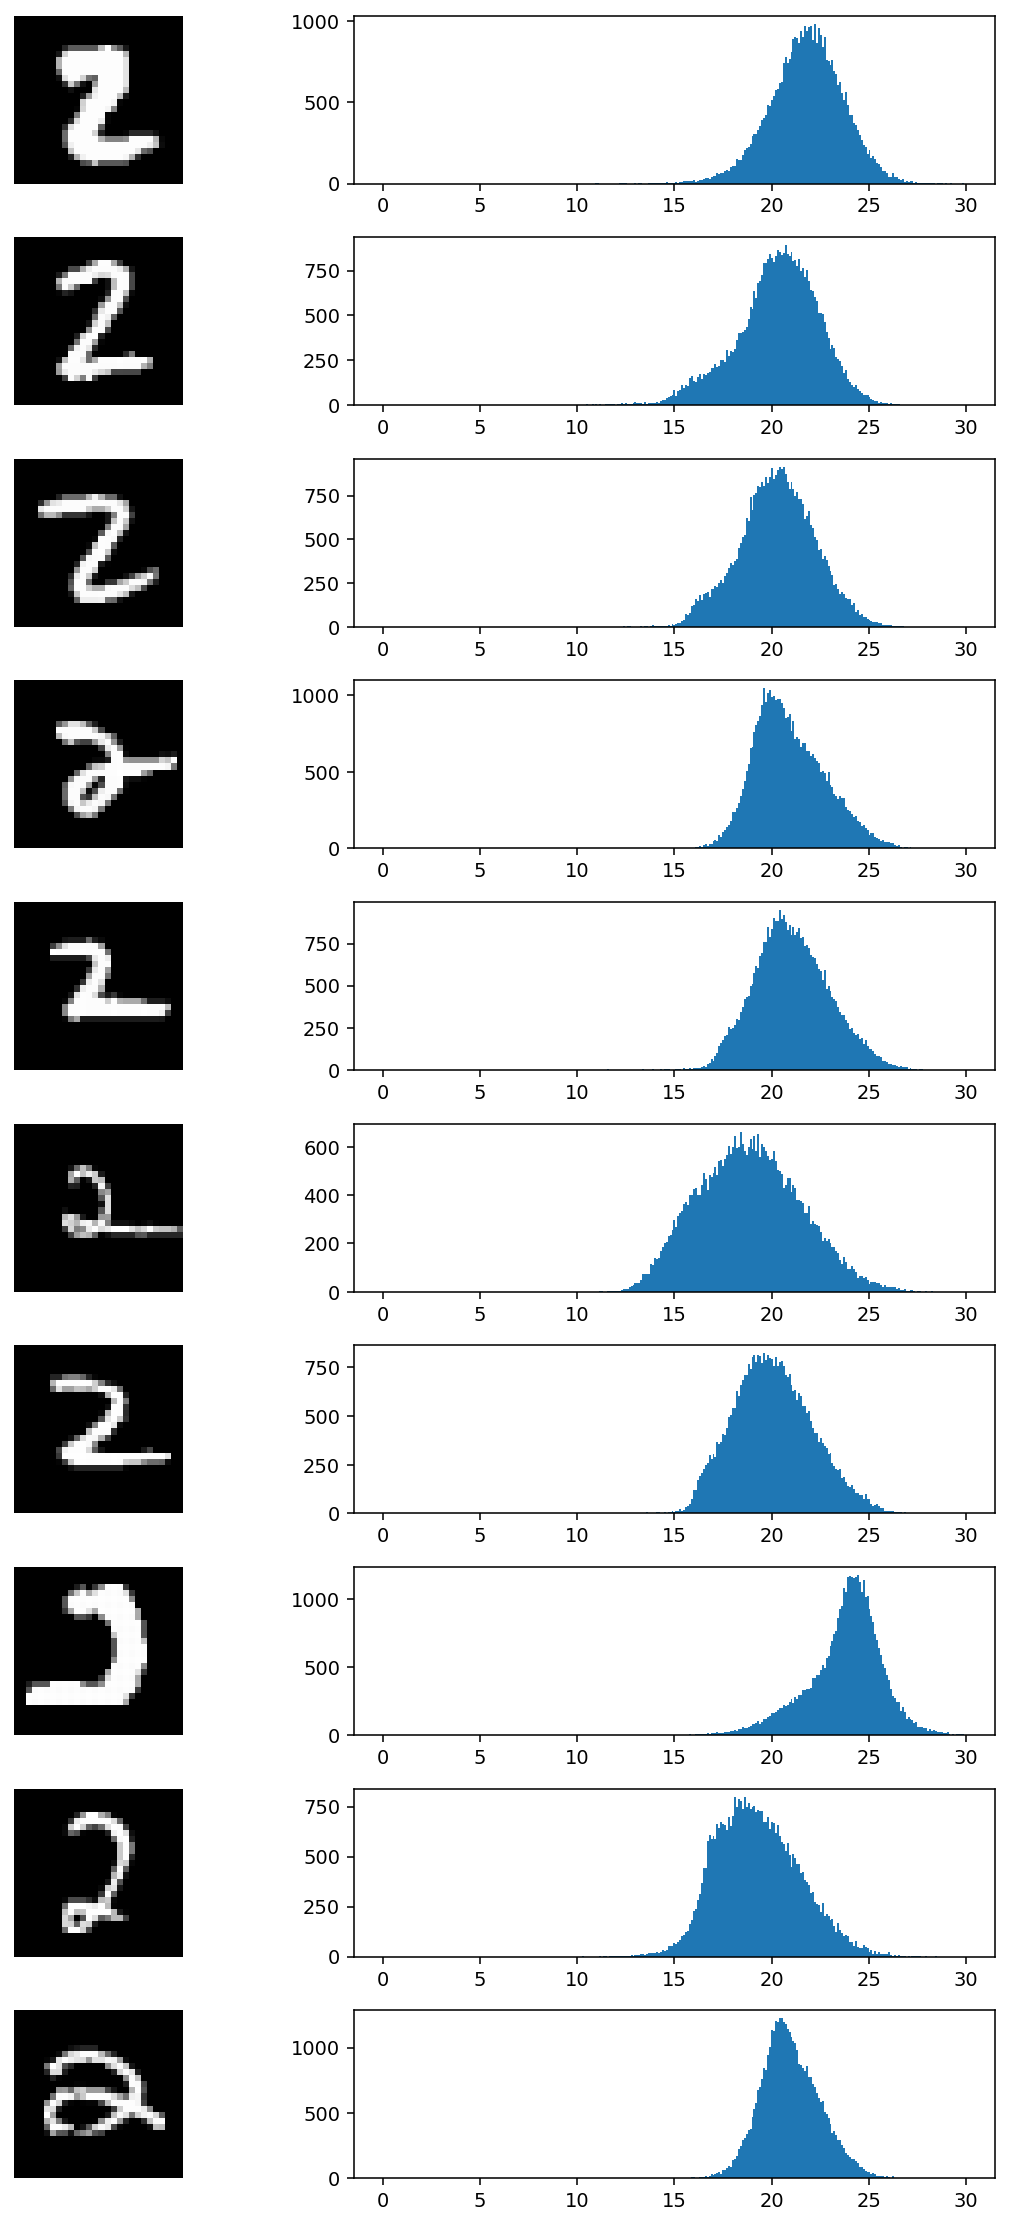

In [ ]:
plot_histograms(all_distances, 2, mnist_df)

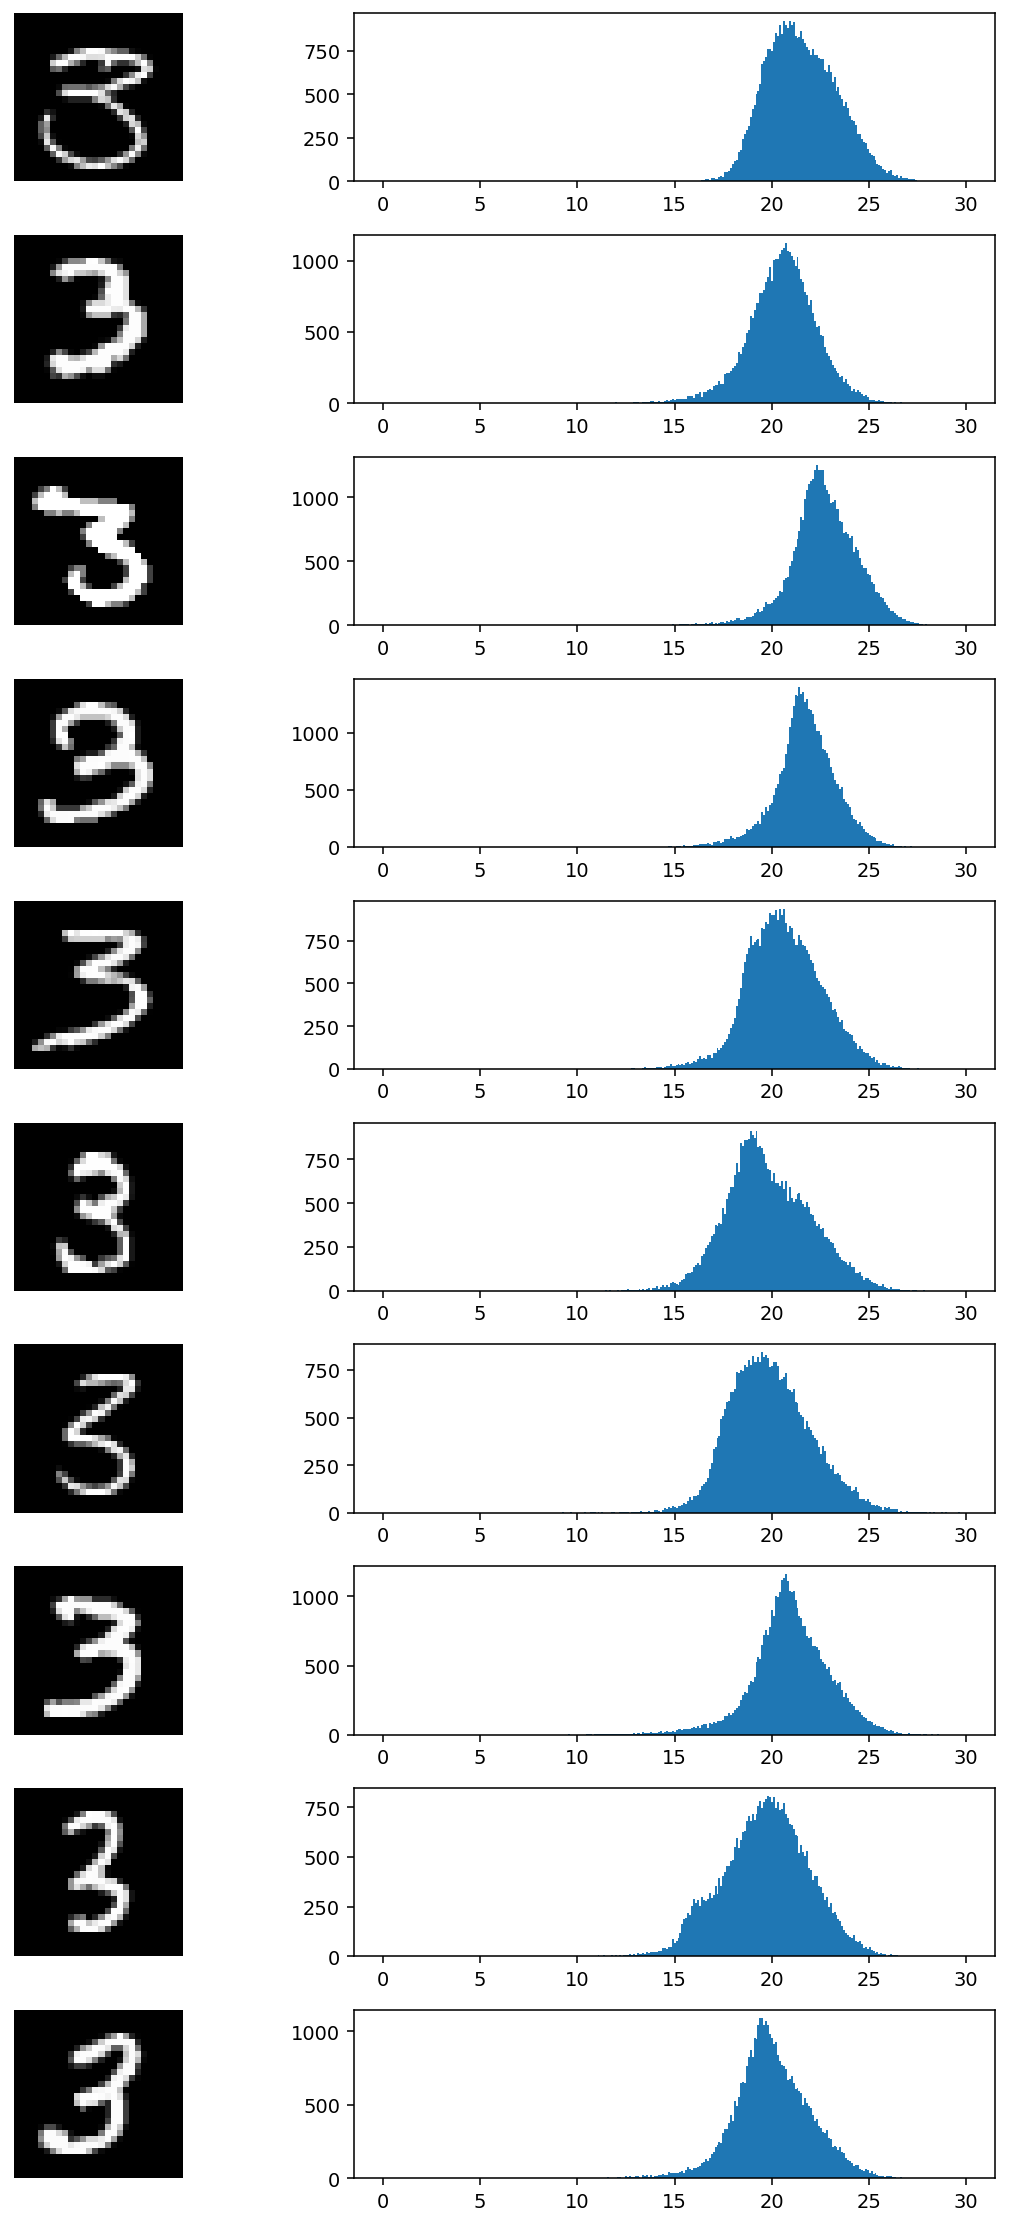

In [ ]:
plot_histograms(all_distances, 3, mnist_df)

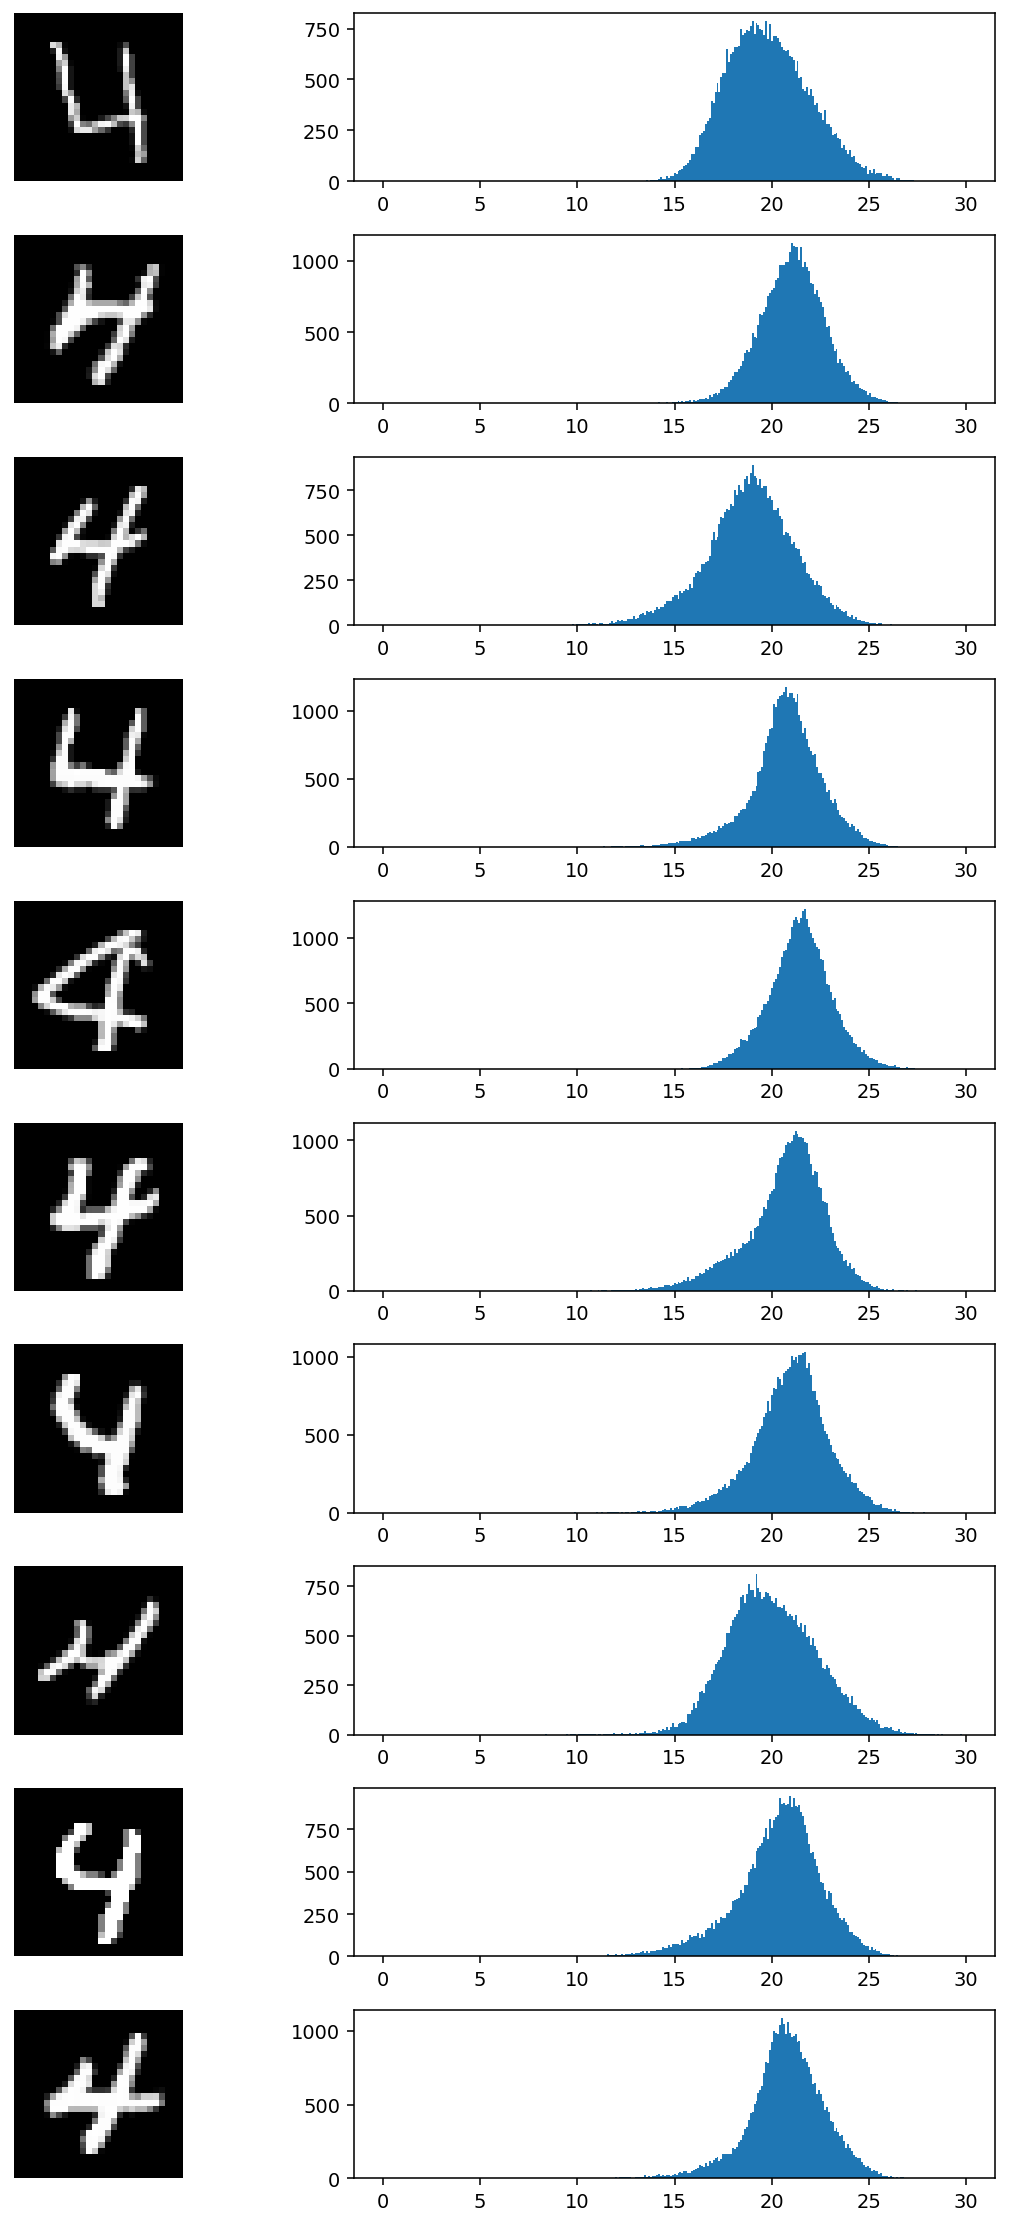

In [ ]:
plot_histograms(all_distances, 4, mnist_df)

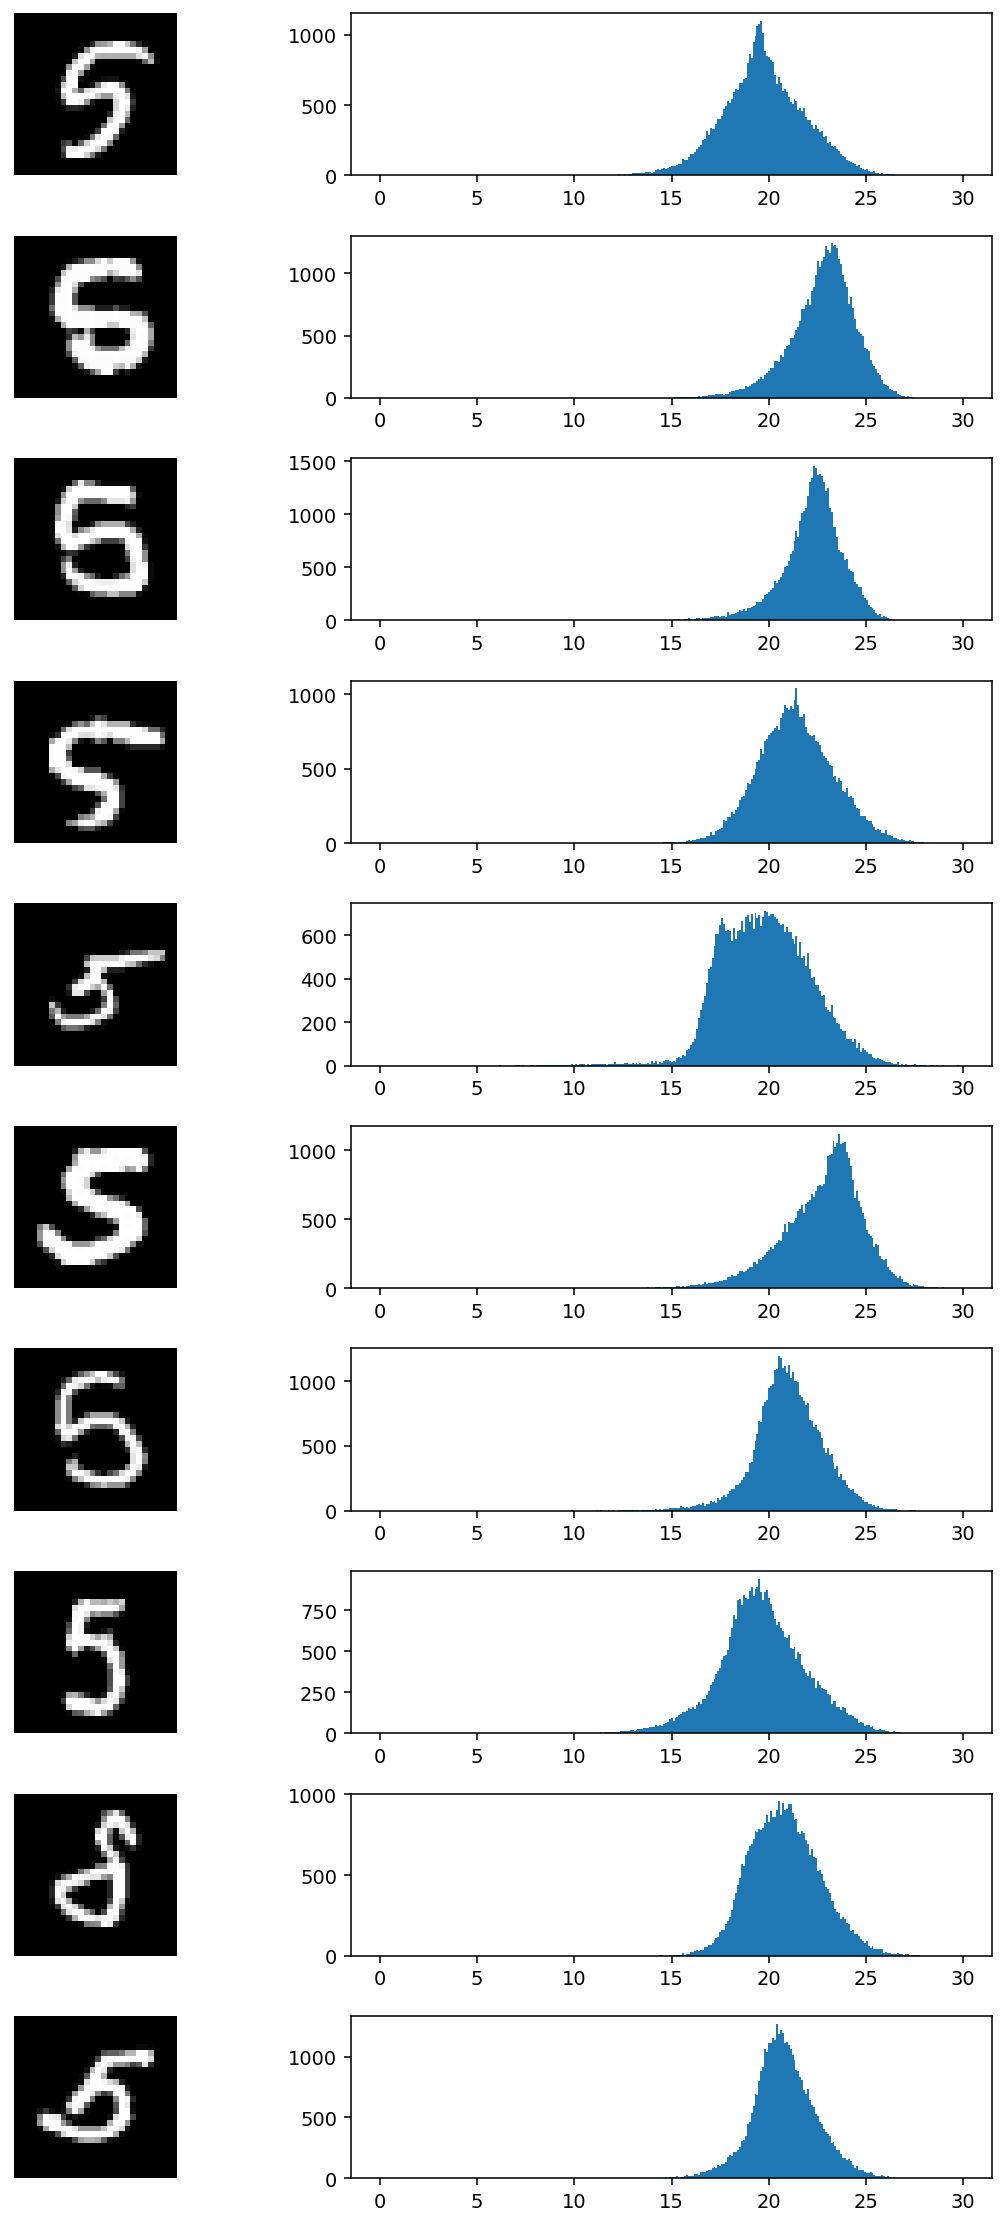

In [ ]:
plot_histograms(all_distances, 5, mnist_df)

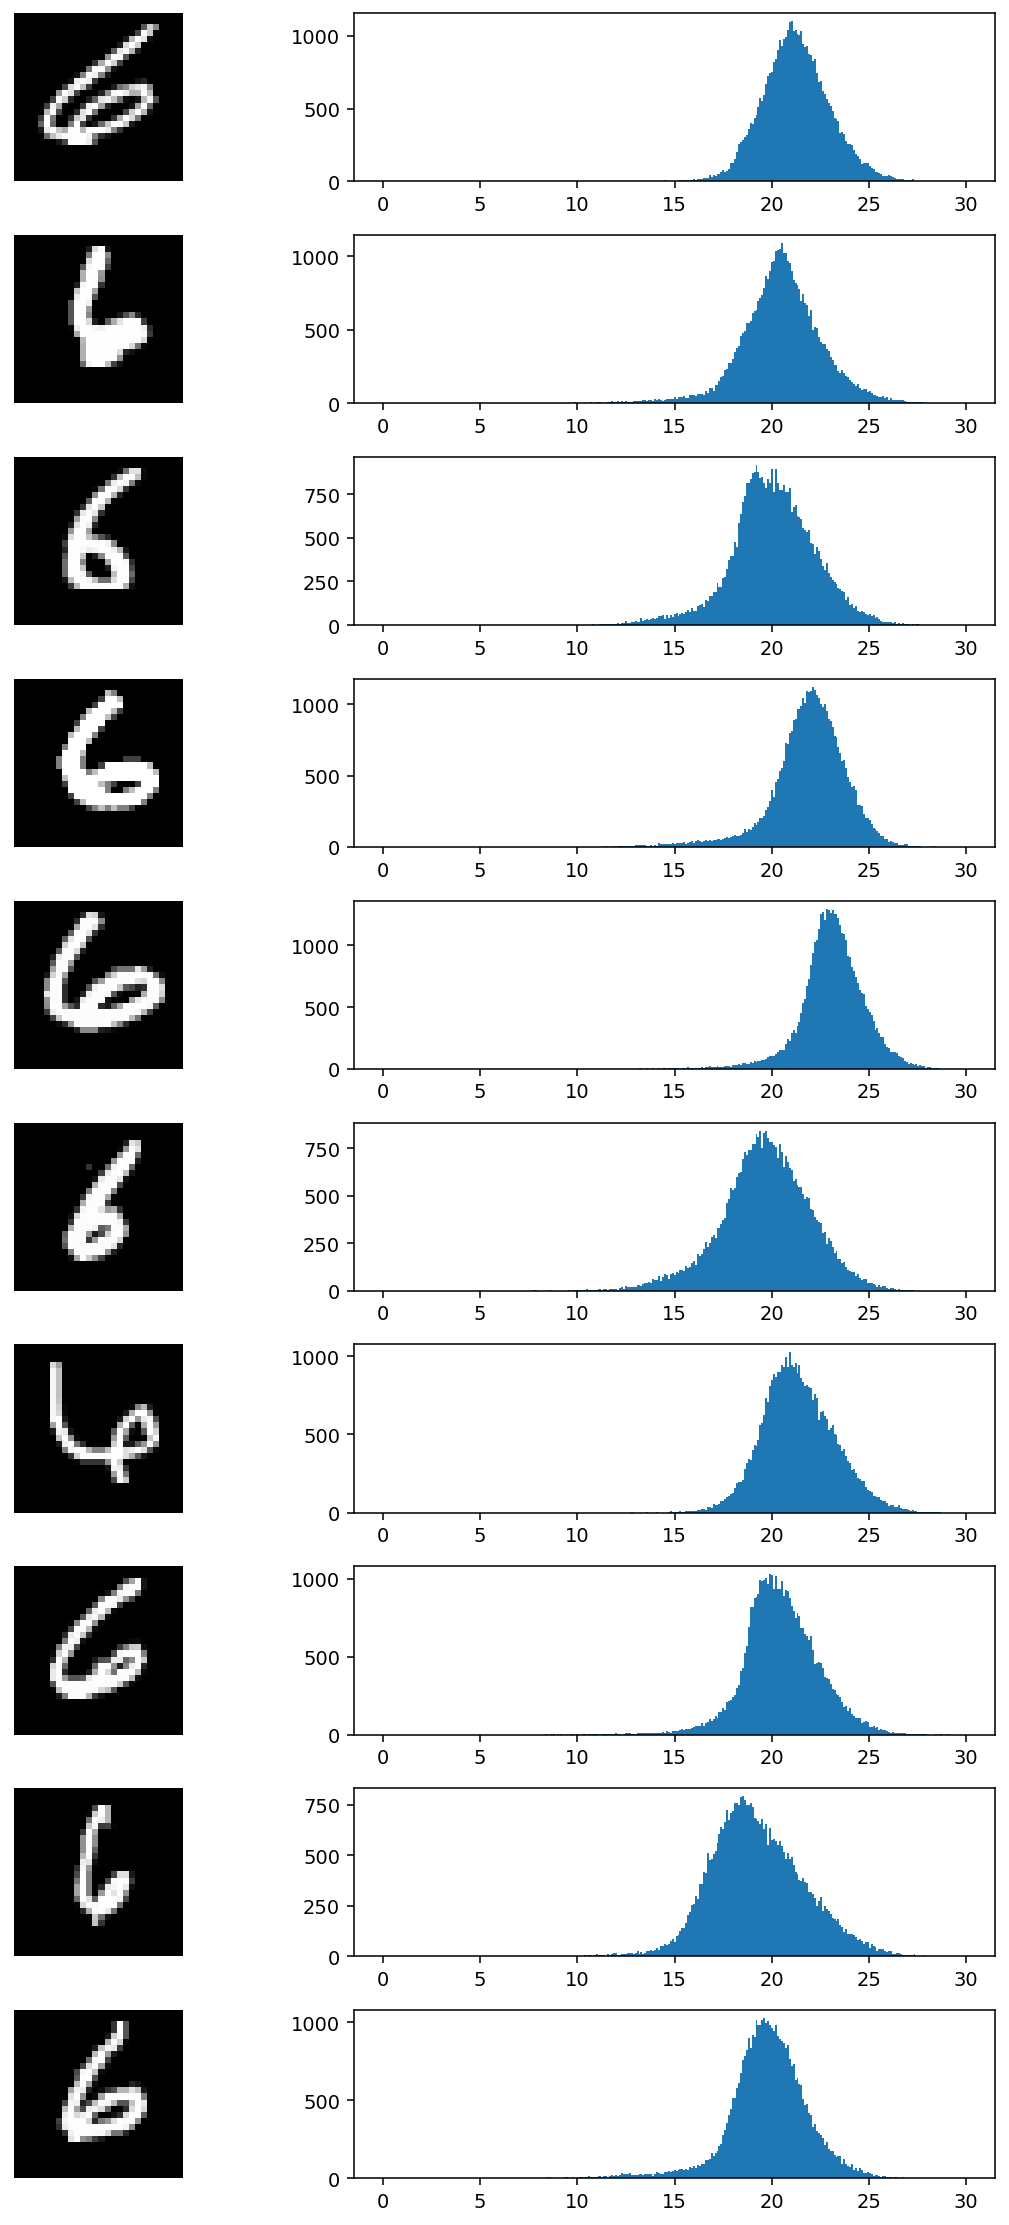

In [ ]:
plot_histograms(all_distances, 6, mnist_df)

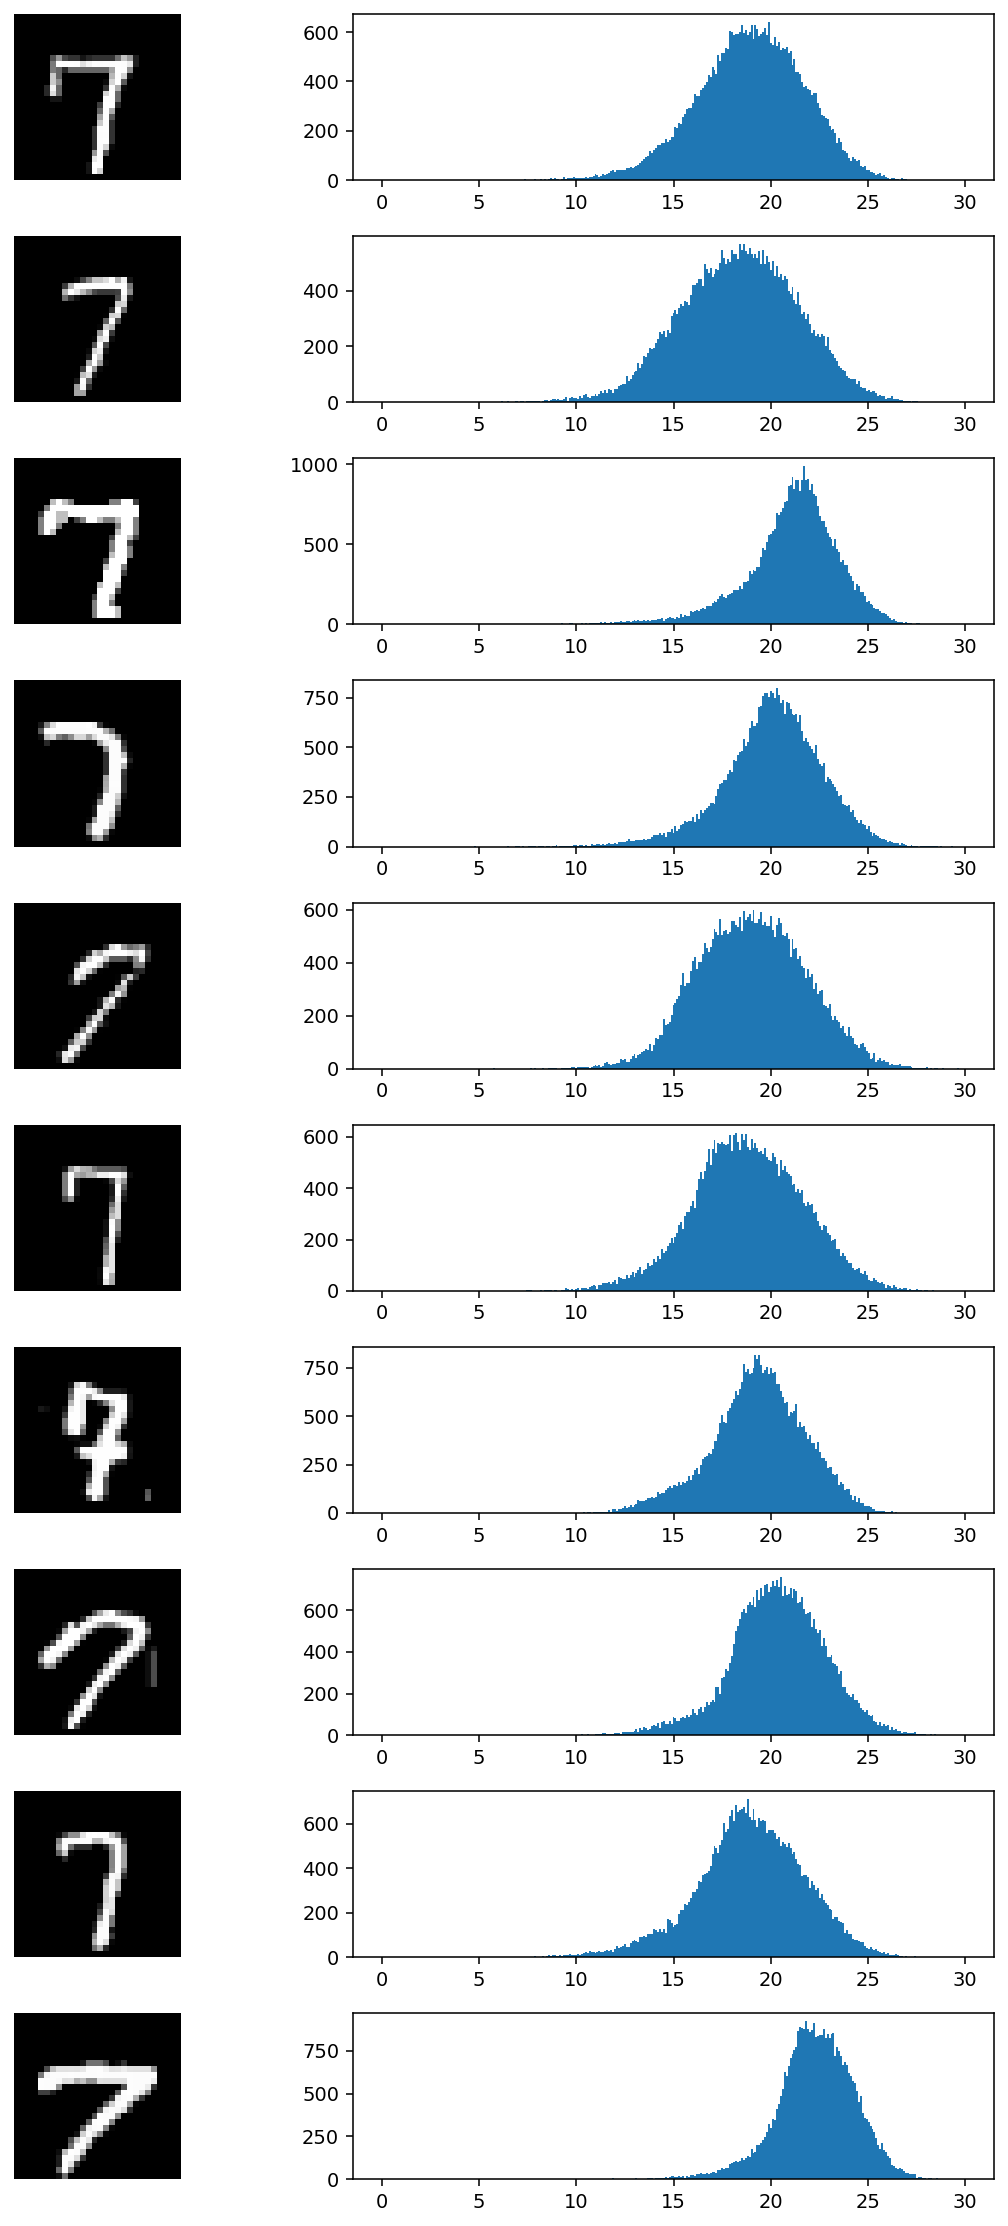

In [ ]:
plot_histograms(all_distances, 7, mnist_df)

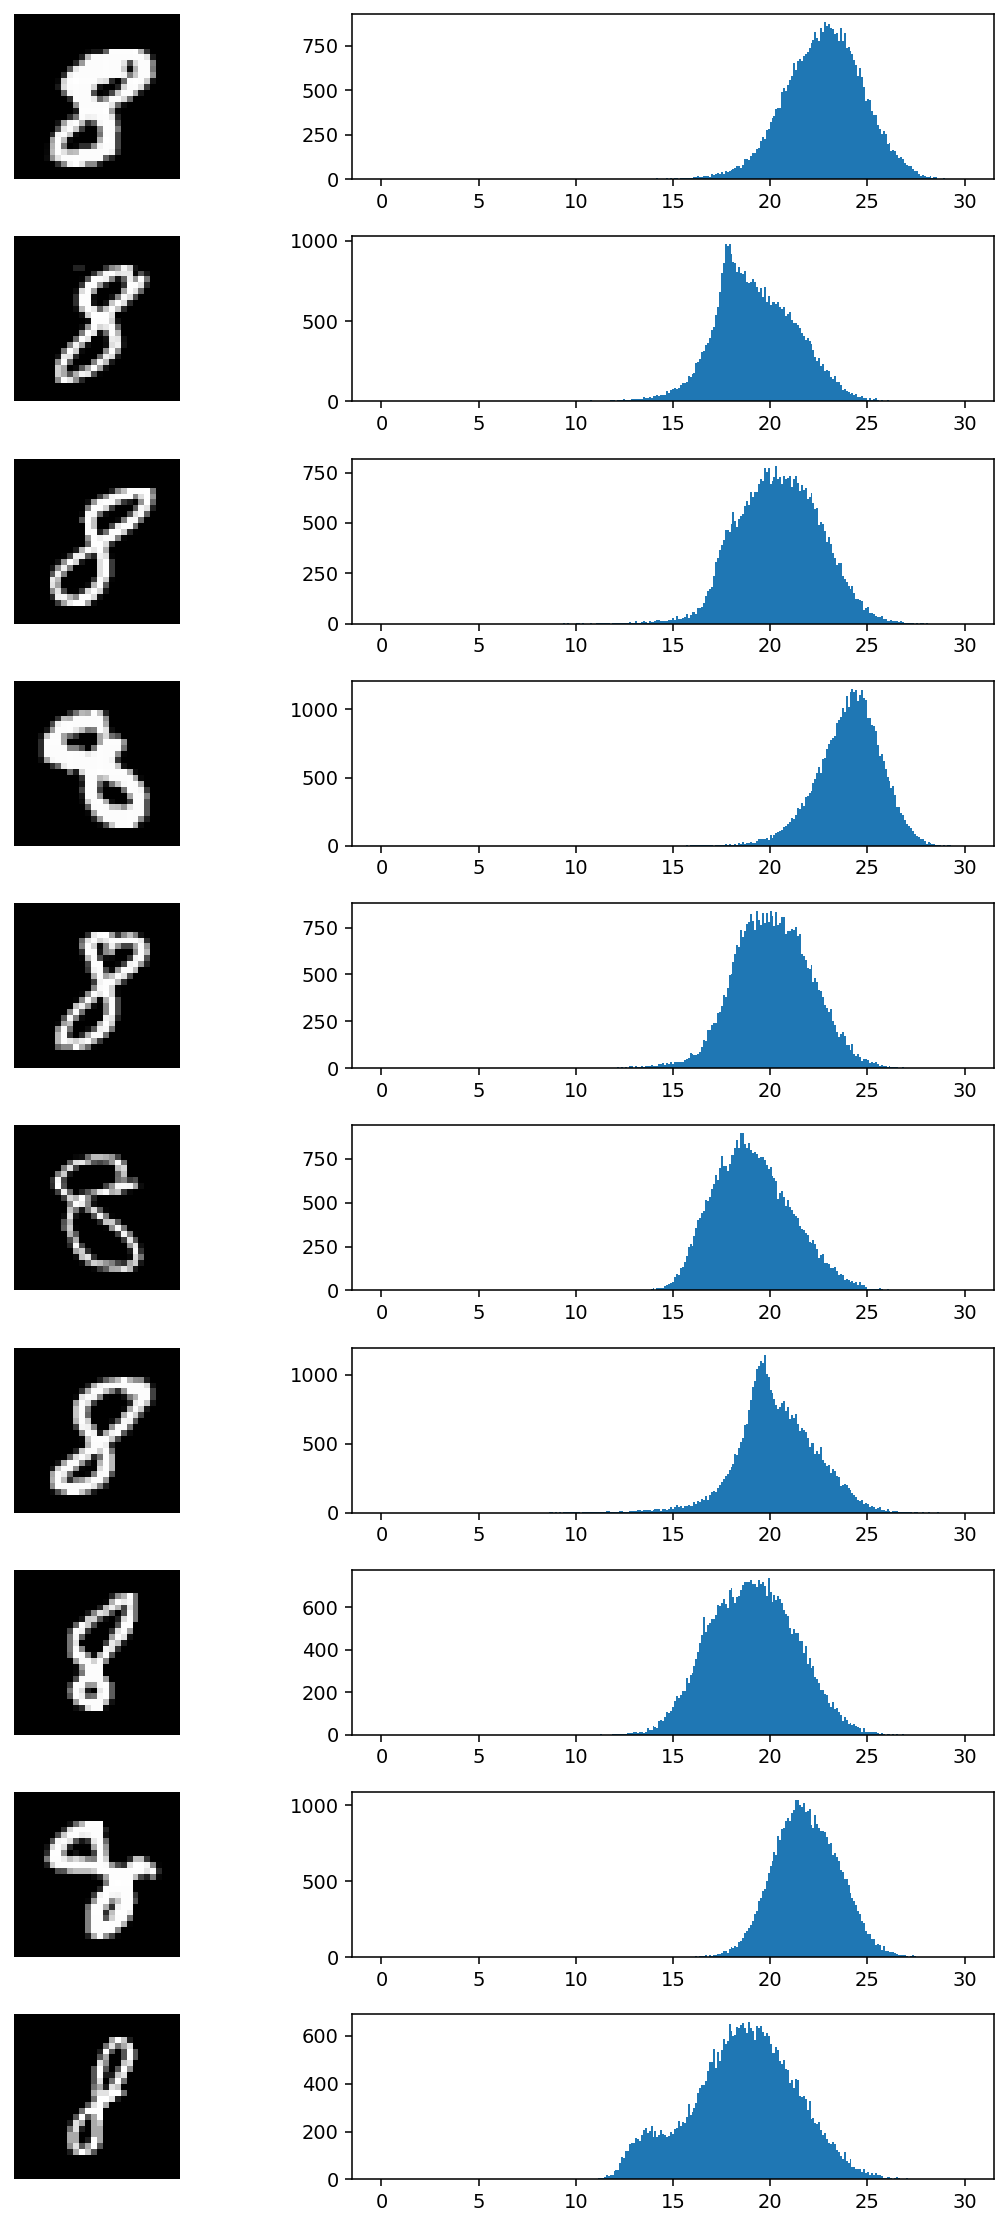

In [ ]:
plot_histograms(all_distances, 8, mnist_df)

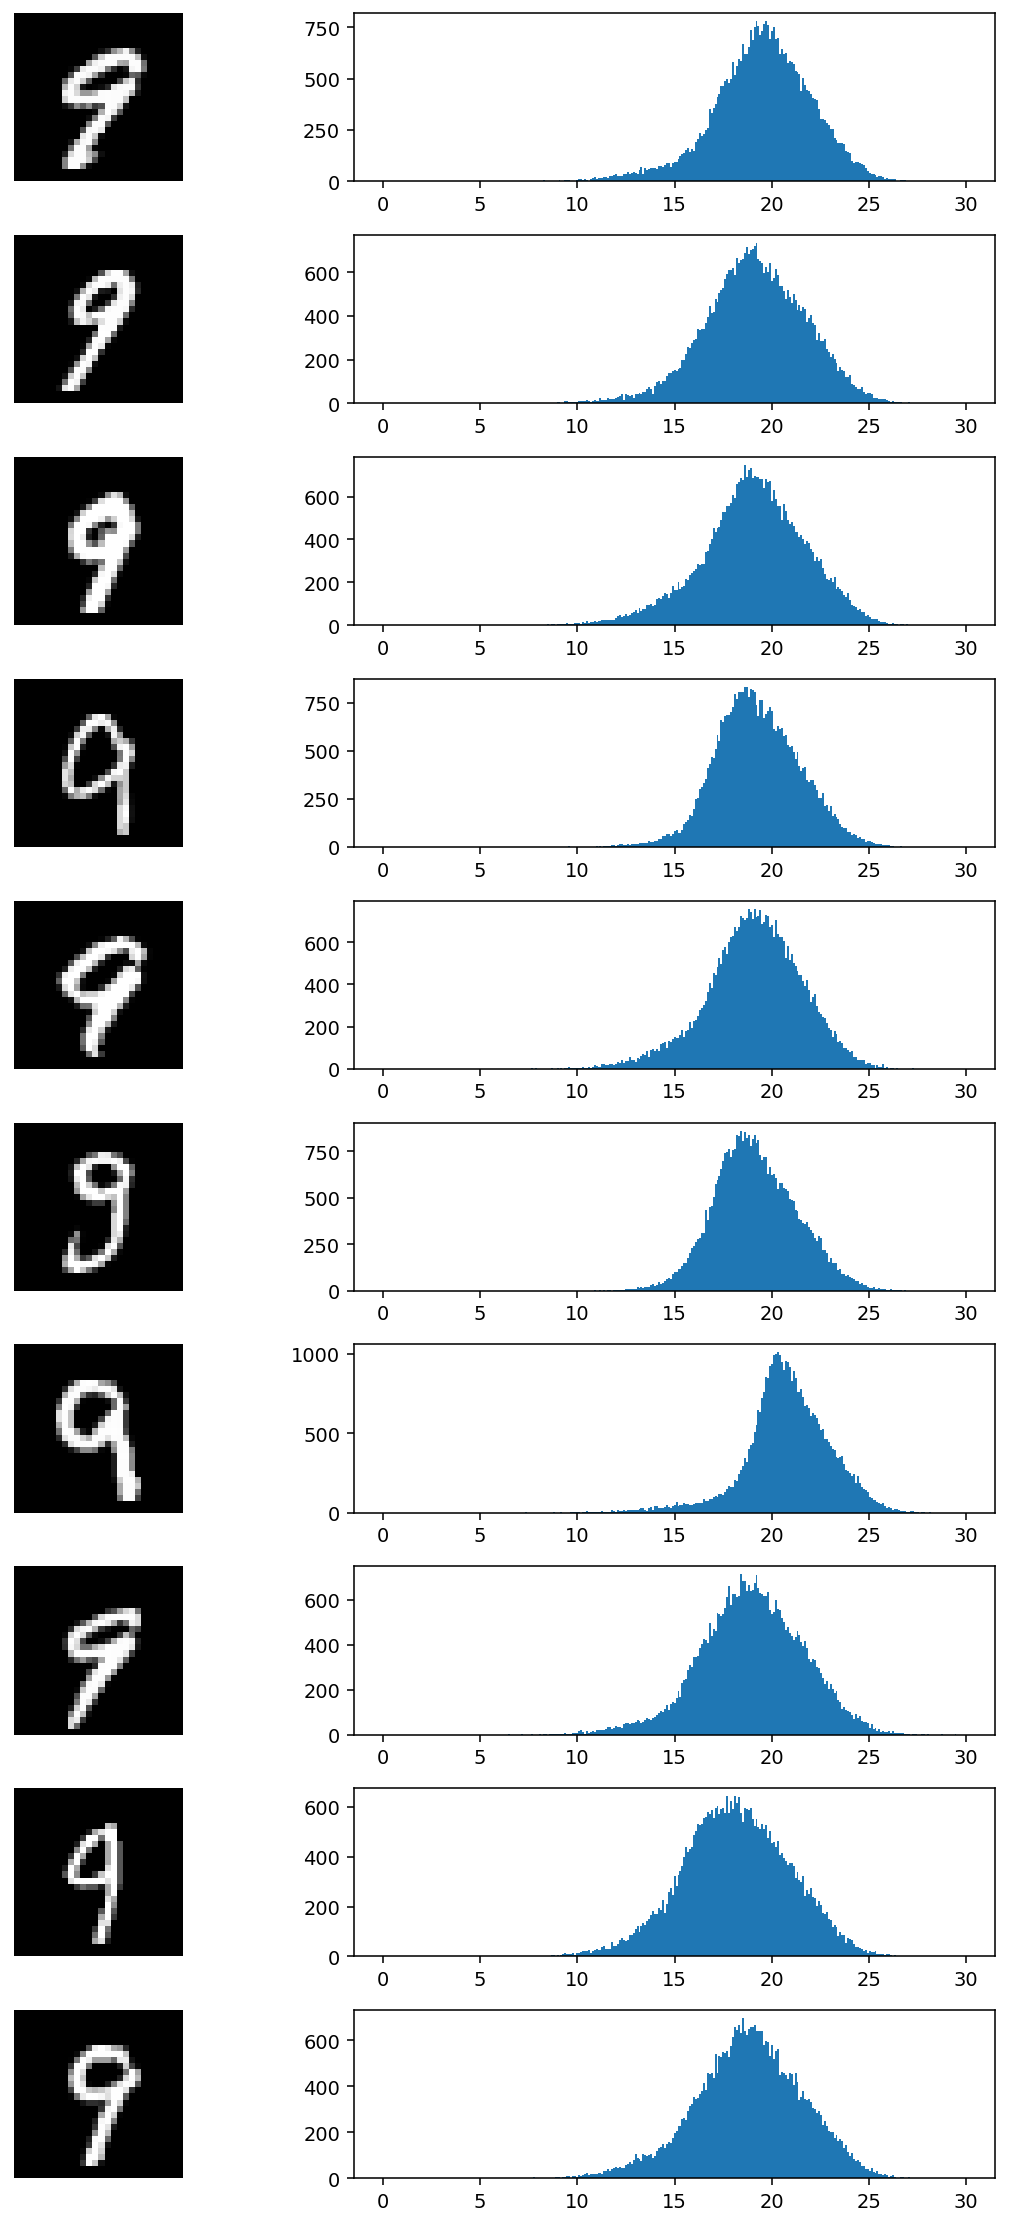

In [ ]:
plot_histograms(all_distances, 9, mnist_df)

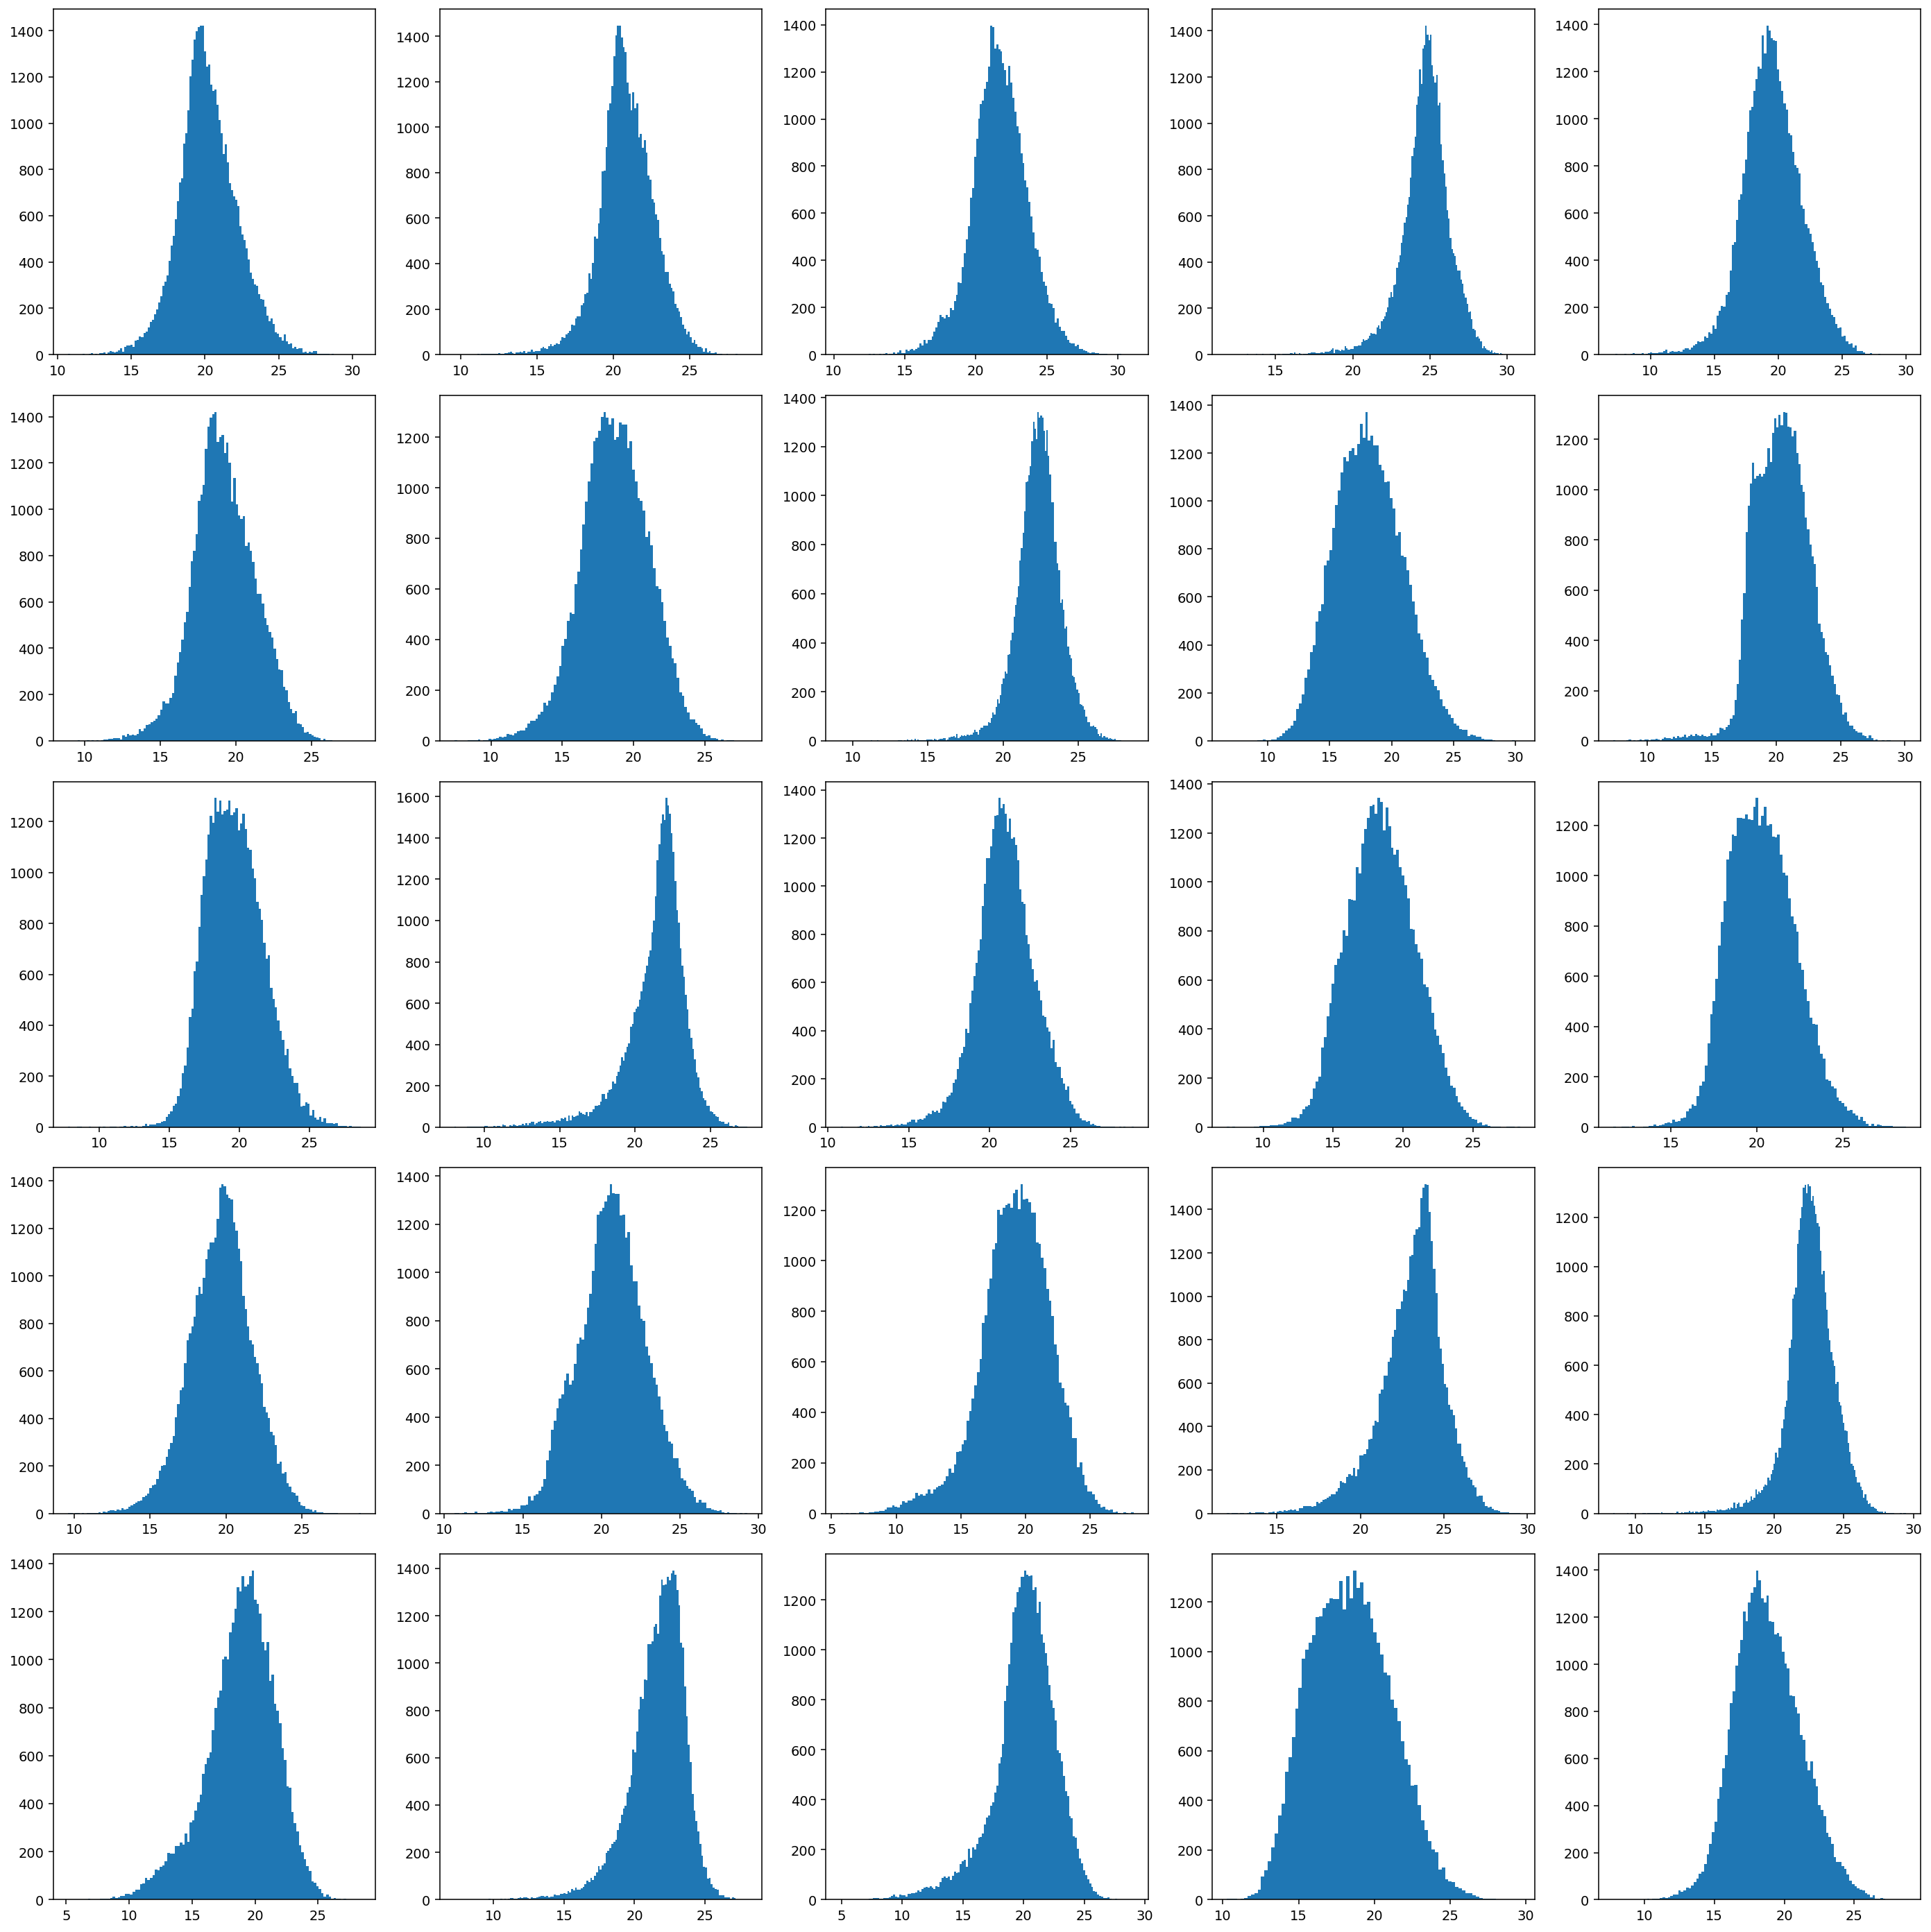

In [ ]:
num_histograms = 25
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()

for i in range(num_histograms):
    random_idx = random.randint(0, 41999)
    distances = np.delete(all_distances[random_idx], random_idx)
    axes[i].hist(distances, bins='auto')
    # axes[i].set_title(f'Index: {random_idx}')
    # axes[i].axis('off') # Hide axes for better visualization

plt.tight_layout()
plt.show()

## Гистограммы расстояний от сгенерированных картинок до остальных из датасета

In [ ]:
cfm_fake_embds = np.load(os.path.join(data_path, 'cfm_fake_embds.npy'))
ddim_fake_embds = np.load(os.path.join(data_path, 'ddim_fake_embds.npy'))

In [ ]:
cfm_distances = euclidean_distances(cfm_fake_embds, orig_embds)
ddim_distances = euclidean_distances(ddim_fake_embds, orig_embds)
cfm_distances.shape, ddim_distances.shape

((3000, 42000), (3072, 42000))

In [ ]:
cfm_fake_imgs = np.load(os.path.join(data_path, 'compare_two_unseen', 'cfm_imgs_3000_newnew.npy'))
ddim_fake_imgs = np.load(os.path.join(data_path, 'ddim_imgs_3072.npy'))

In [ ]:
def plot_histograms_fake(distances, images):
    fig, axes = plt.subplots(10, 2, figsize=(9, 16))
    idxs = np.random.randint(len(images), size=10)

    for i, idx in enumerate(idxs):
        image = np.reshape(images[idx], (28, 28))
        dist = distances[idx]

        axes[i, 0].imshow(image, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 1].hist(dist, bins=np.linspace(0, 30, 300))
        # axes[i, 1].hist(dist, bins='auto')

    plt.tight_layout()
    plt.show()


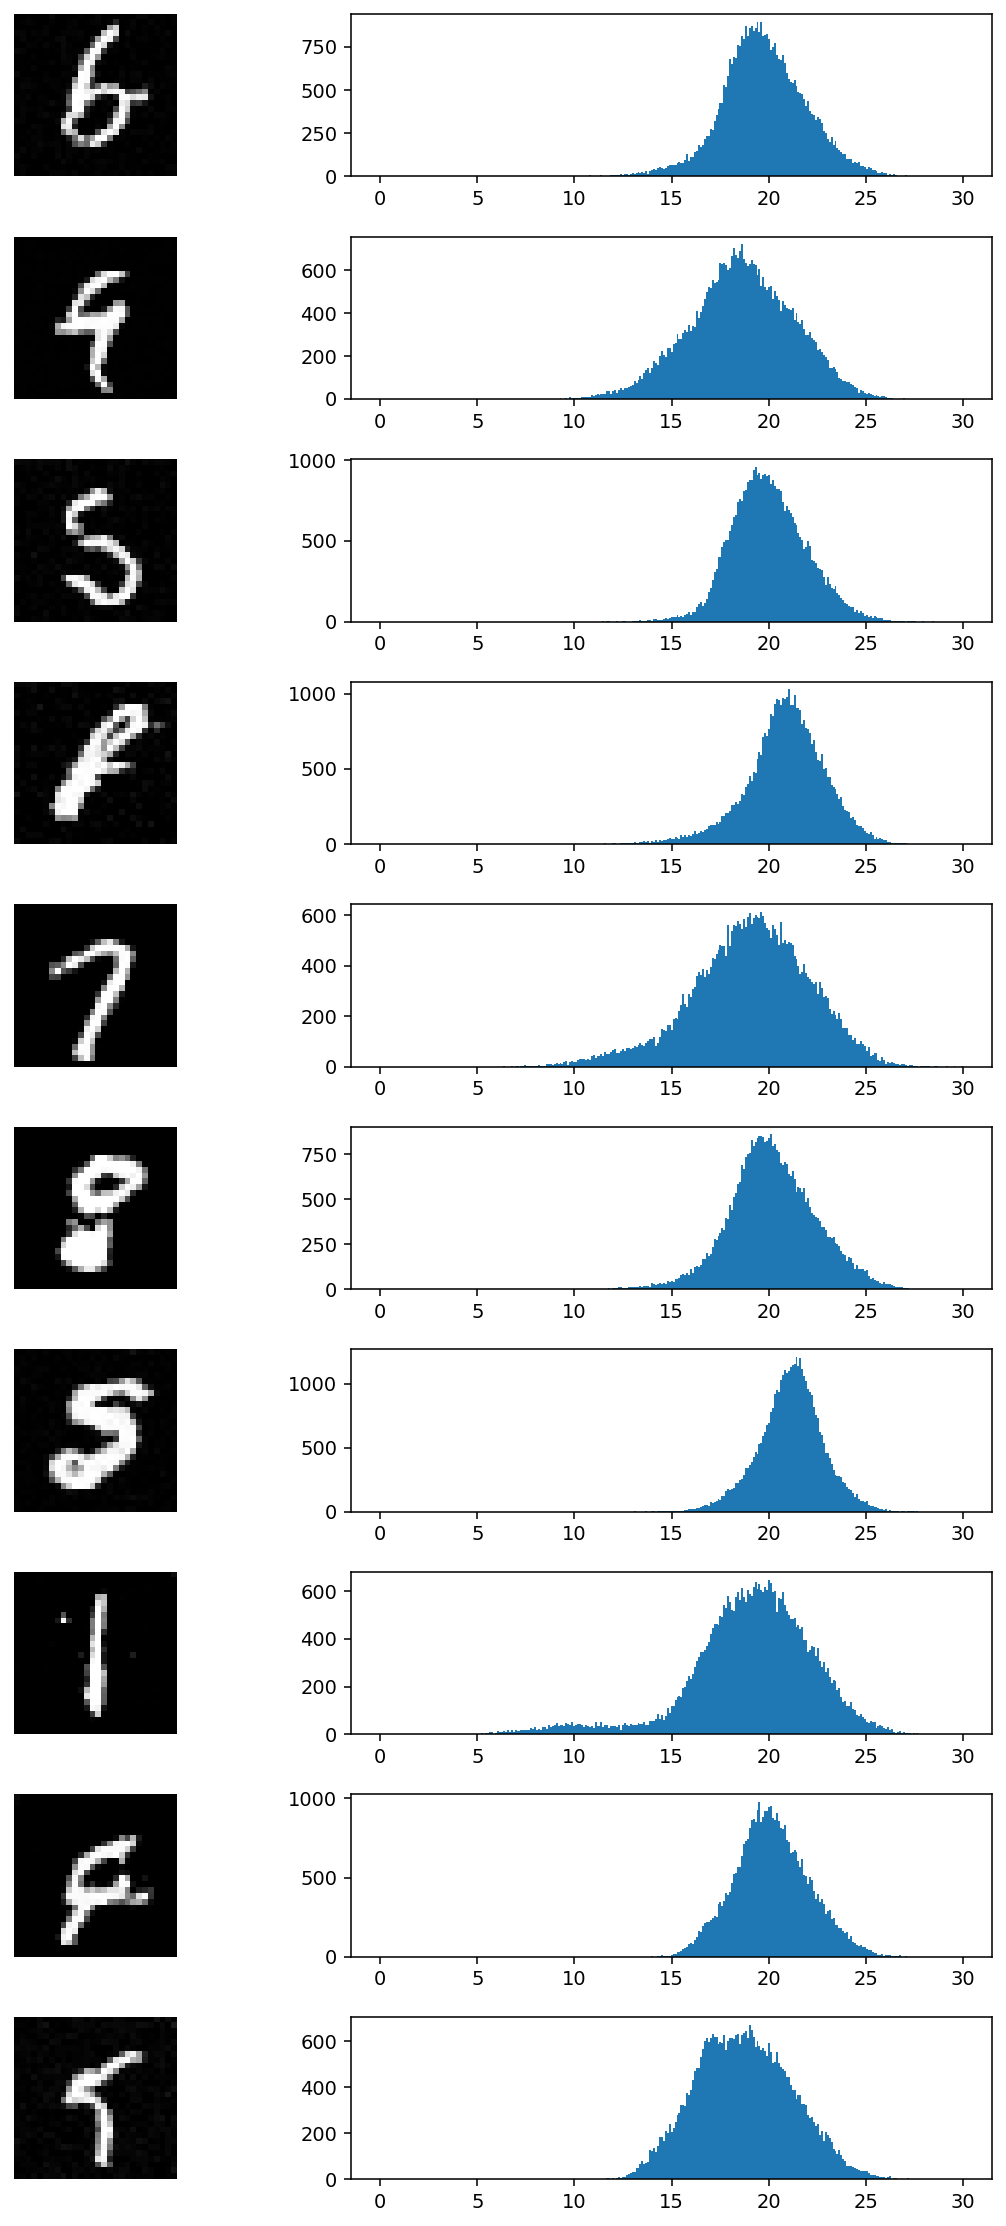

In [ ]:
plot_histograms_fake(cfm_distances, cfm_fake_imgs)

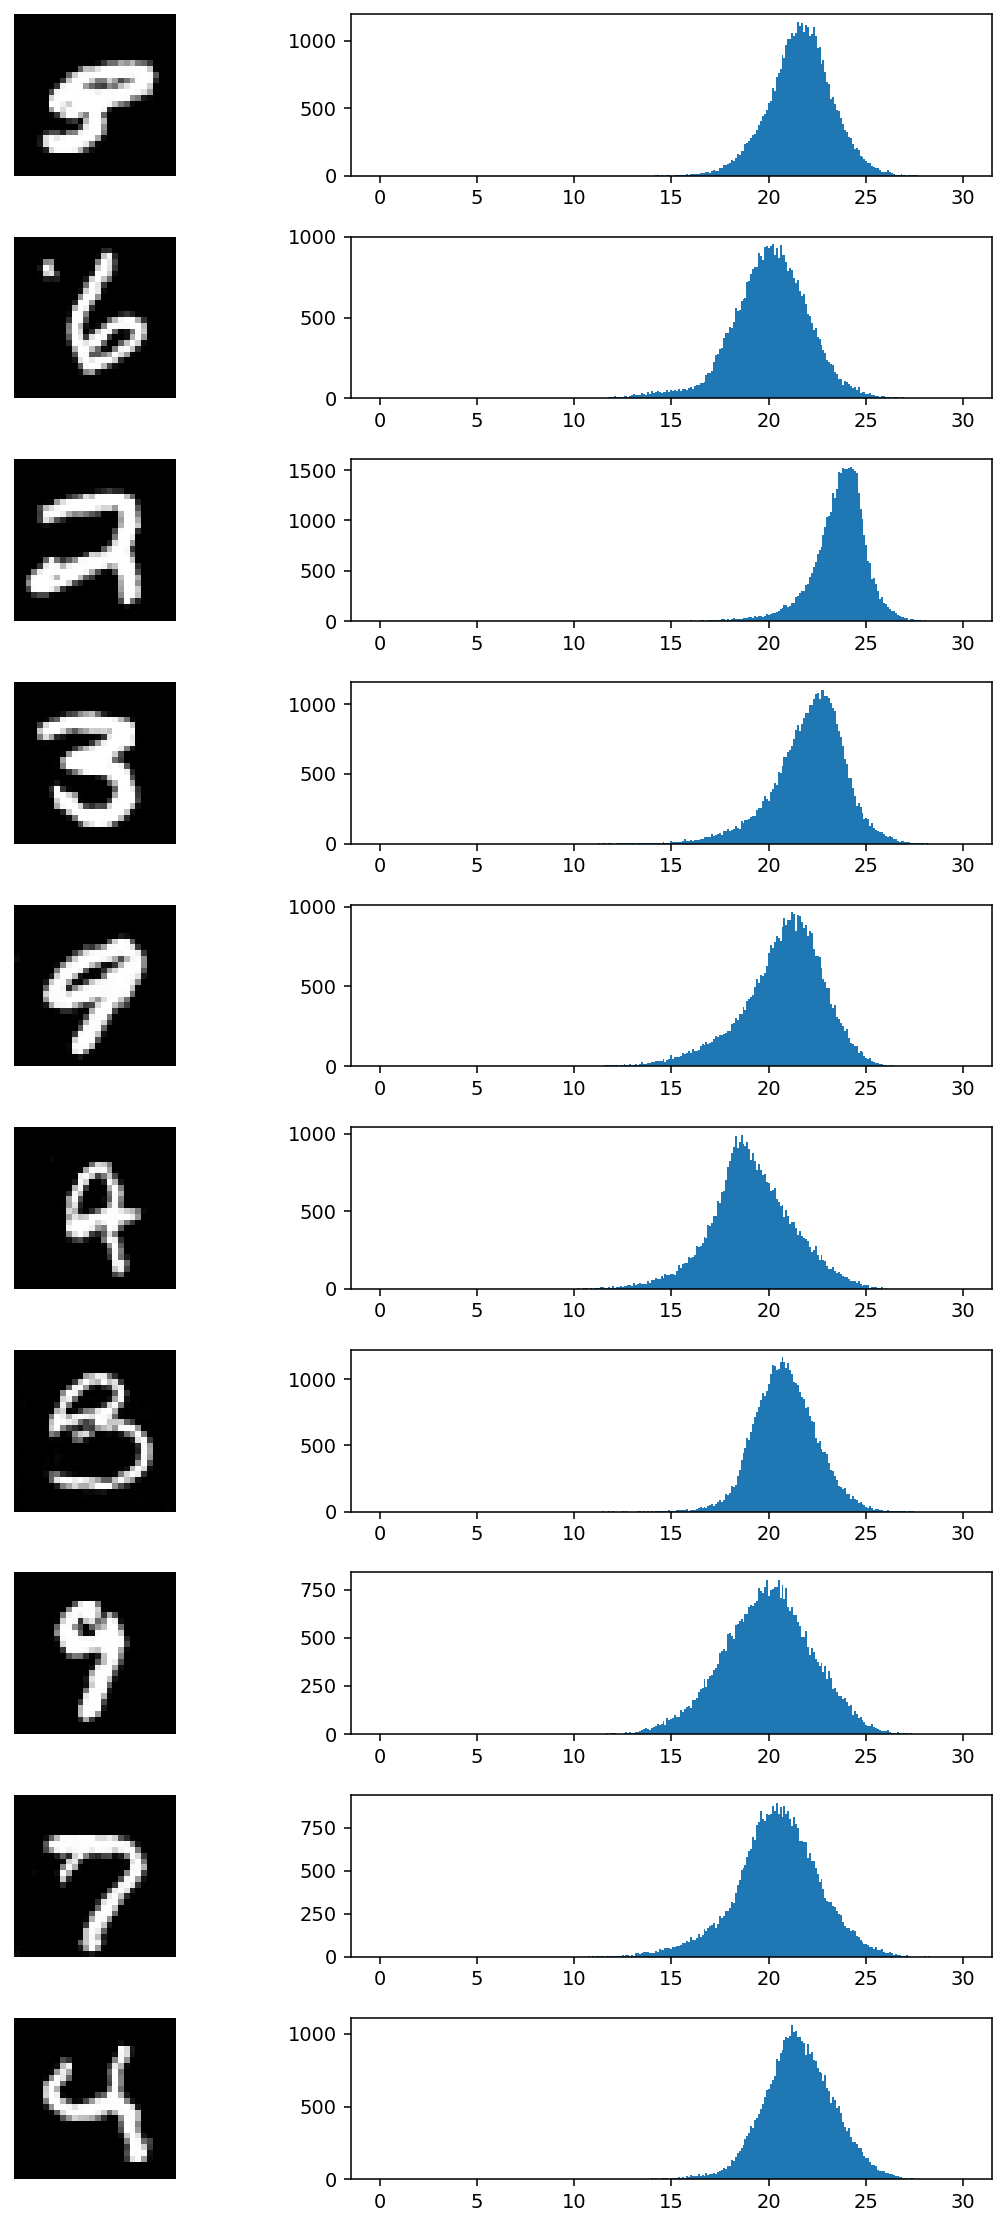

In [ ]:
plot_histograms_fake(ddim_distances, ddim_fake_imgs)

In [ ]:
def plot_beginning_histograms_fake(distances, images):
    fig, axes = plt.subplots(10, 2, figsize=(9, 16))
    idxs = np.random.randint(len(images), size=10)

    for i, idx in enumerate(idxs):
        image = np.reshape(images[idx], (28, 28))
        dist = distances[idx]
        beginning_dist = np.sort(dist)[:len(dist)//10]

        axes[i, 0].imshow(image, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 1].hist(beginning_dist, bins=np.linspace(beginning_dist.min(), beginning_dist.max(), 150))
        # axes[i, 1].hist(dist, bins='auto')

    plt.tight_layout()
    plt.show()


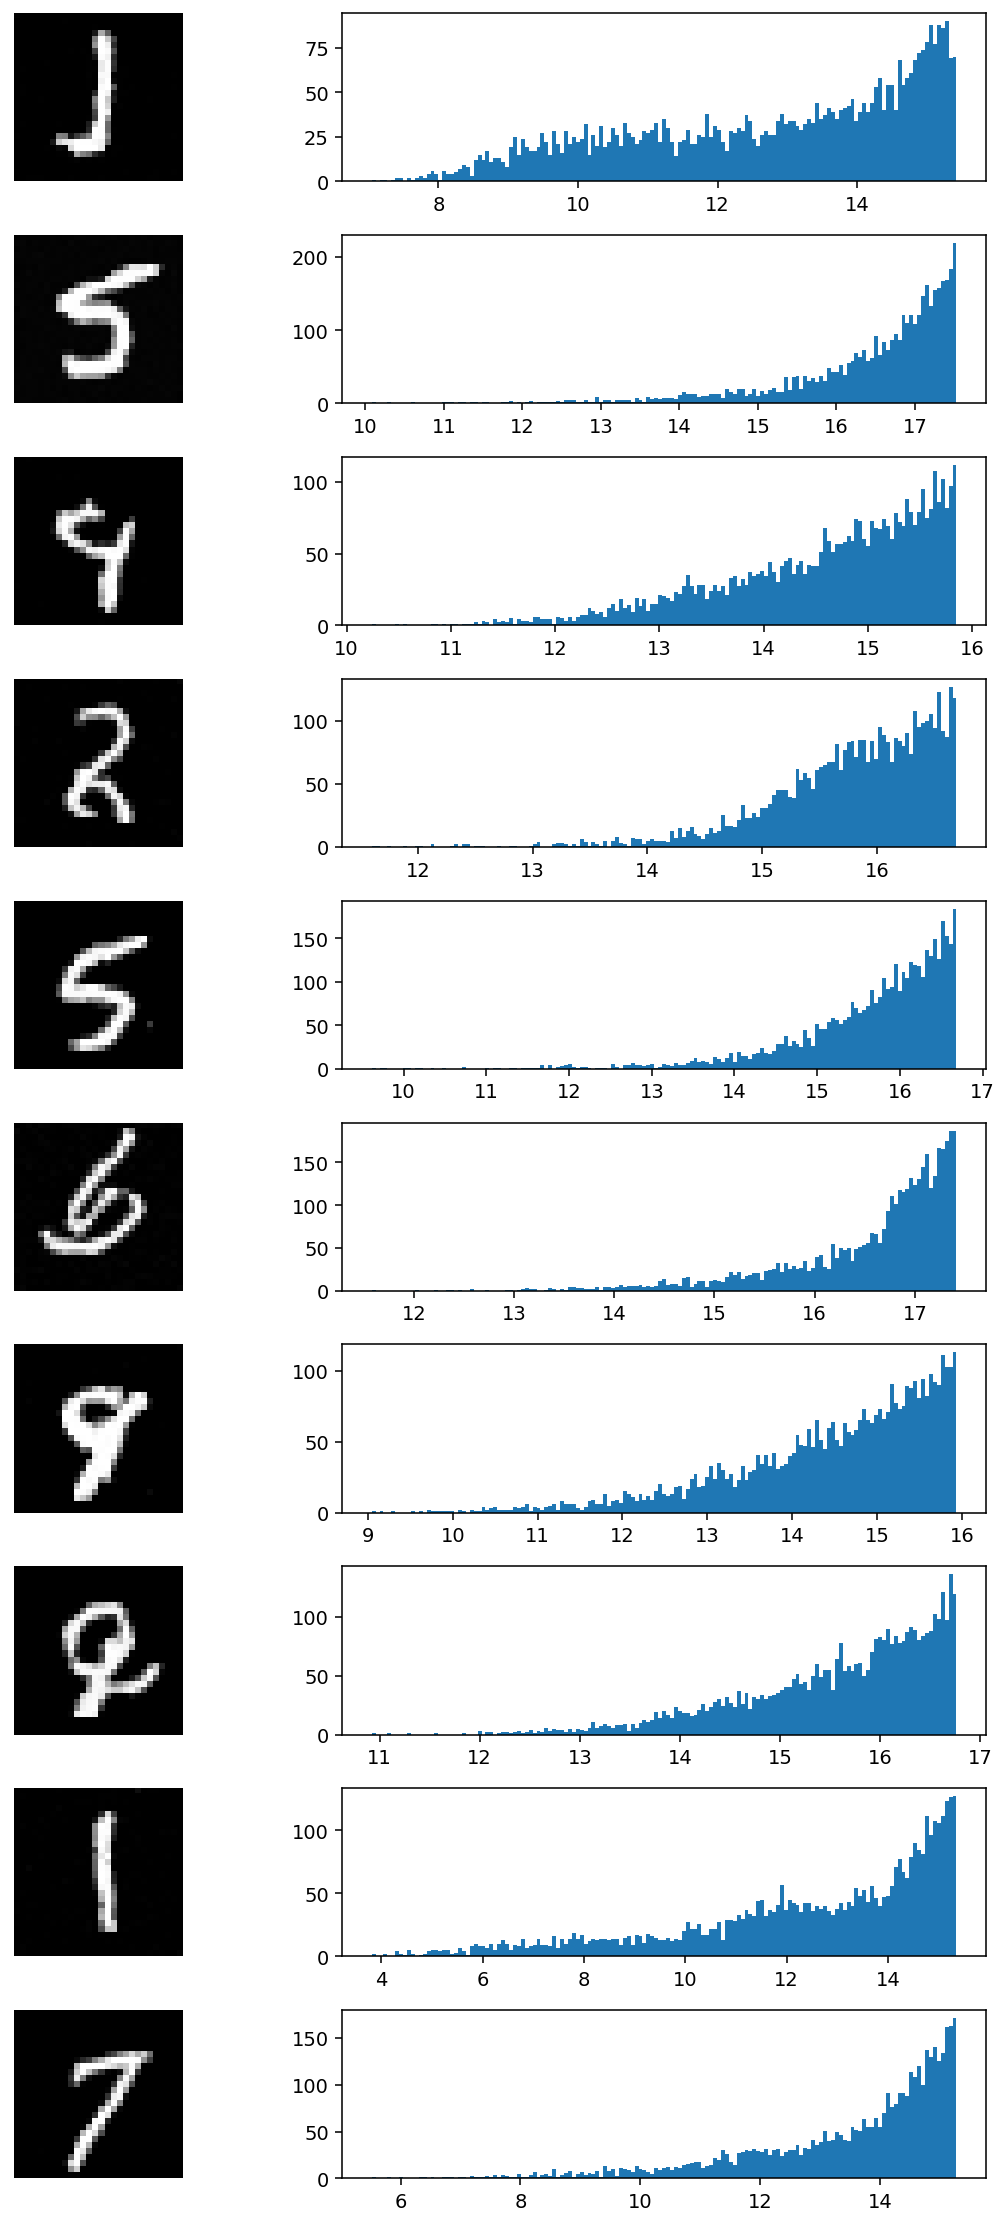

In [ ]:
plot_beginning_histograms_fake(cfm_distances, cfm_fake_imgs)

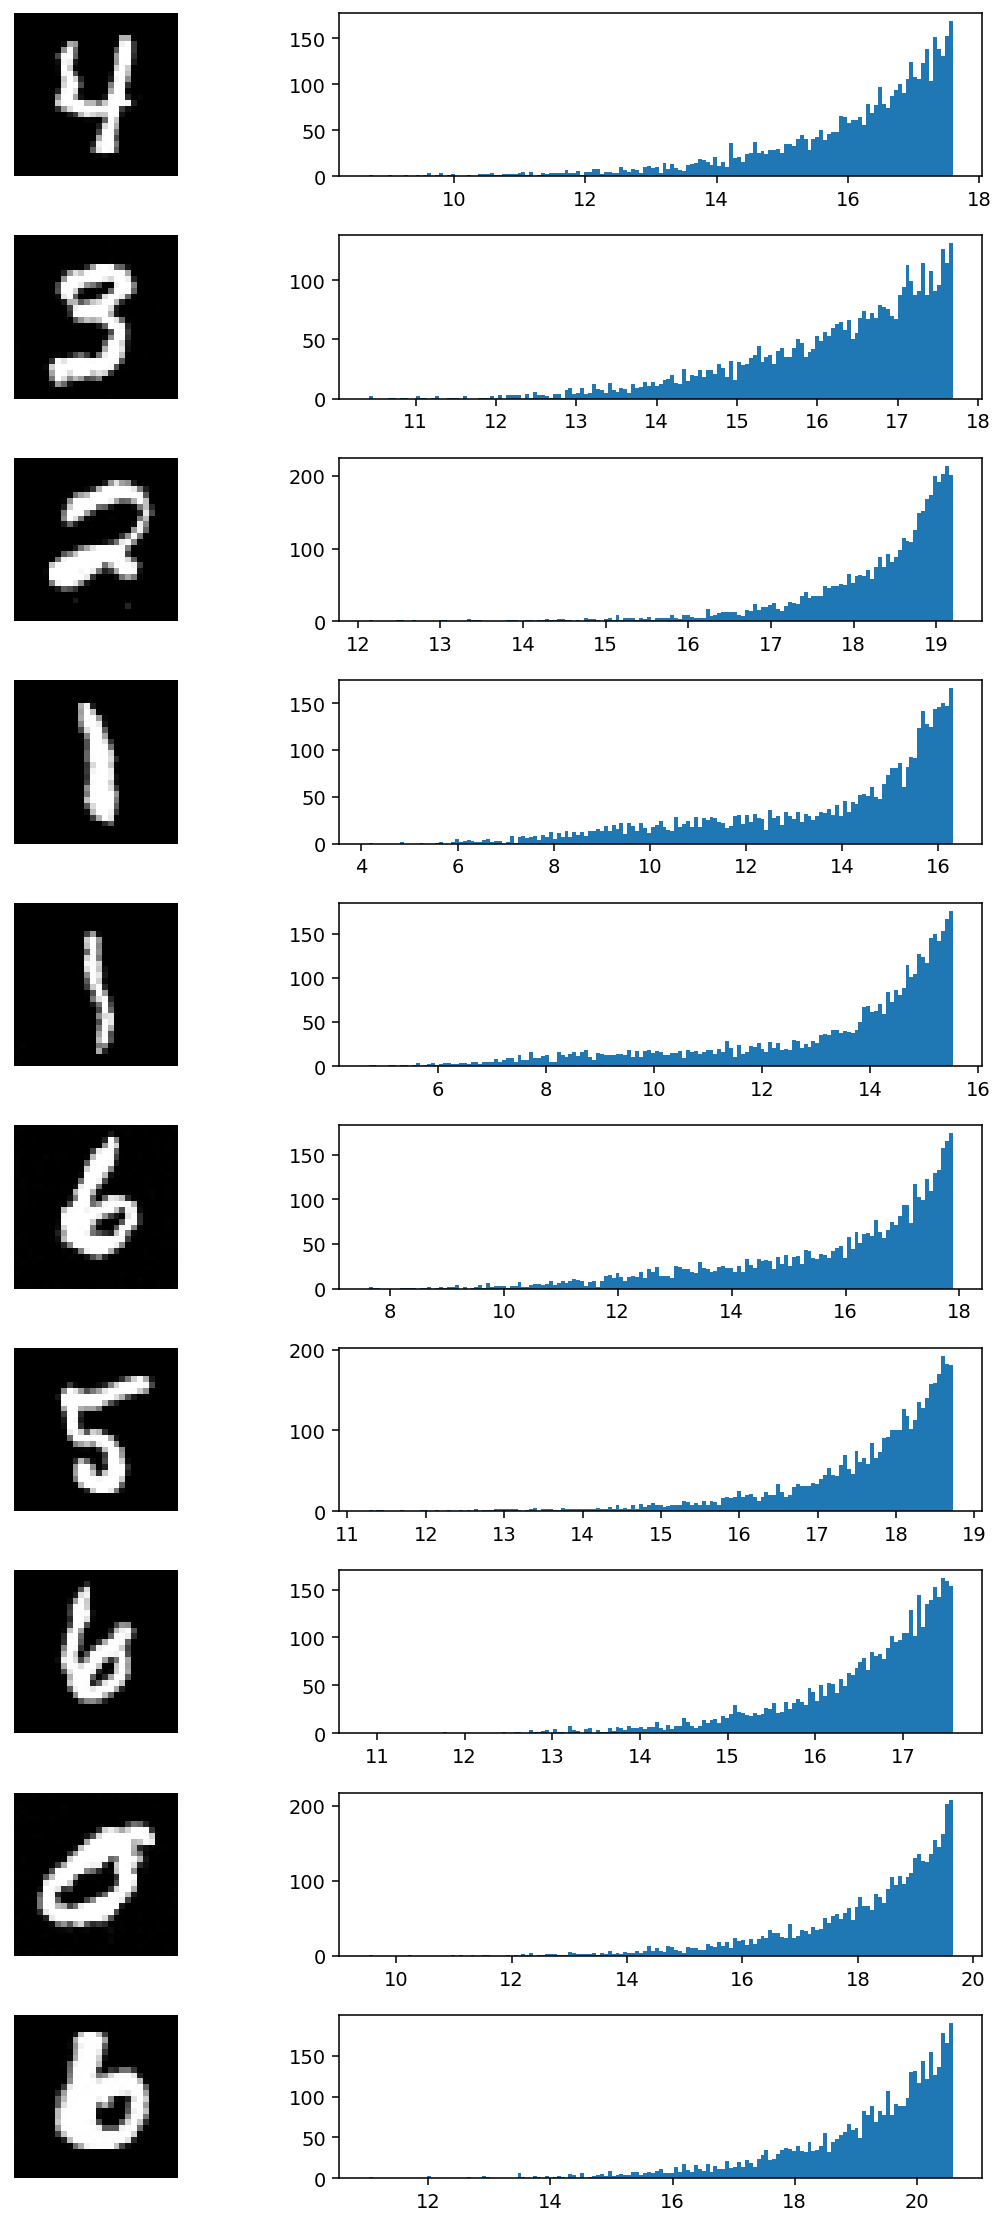

In [ ]:
plot_beginning_histograms_fake(ddim_distances, ddim_fake_imgs)

# Сравнение распределений расстояний от настоящей точки до всех остальных в датасете, и от сгенерированной точки (близкой к настоящей по эмбеддингу) до всех остальных в датасете

План 1 (расстояния считаем внутри своих датасетов):

1. Нагенерировать ~60k картинок из гиперкуба, сохраняя исходные шумы
2. Выбрать точку из реального распределения
3. Найти ближайшую по эмбеддингу фейк точку
4. Посчитать расстояния от настоящей до всех остальных реальных --> упорядочить --> взять первые 1000 --> построить гистограмму
5. Посчитать расстояния от фейк до всех остальных фейковых --> упорядочить --> взять первые 1000 --> построить гистограмму
6. Зафиттить кривые на оба графика

План 2 (расстояния считаем внутри реального датасета):

1. Выбрать точку из реального распределения
2. Найти ближайшую по эмбеддингу фейк точку
3. Посчитать расстояния от настоящей до всех остальных реальных --> упорядочить --> взять первые 1000 --> построить гистограмму
4. То же самое сделать с фейк точкой
5. Зафиттить кривые на оба графика

In [ ]:
orig_embds = np.load(os.path.join(data_path, 'distances_distribution', 'train_embds_42000.npy'))
orig_embds.shape

(42000, 100)

In [ ]:
ddim_embds = np.load(os.path.join(data_path, 'ddim_fake_embds_42000.npy'))
ddim_embds.shape

(42000, 100)

In [ ]:
ddim_fake_imgs = np.load(os.path.join(data_path, 'ddim_imgs_42000.npy'))
ddim_fake_imgs.shape

(42000, 784)

In [ ]:
mnist_df = pd.read_csv('train.csv')

In [ ]:
random_idx = 14139 # 555
random_image = mnist_df.iloc[random_idx].filter(regex='pixel').values
random_image = np.reshape(random_image, (28, 28)).astype(np.uint8)

orig_embd = orig_embds[random_idx]

In [ ]:
ddim_distances_to_orig = euclidean_distances(orig_embd[None, ...], ddim_embds)
ddim_distances_to_orig = ddim_distances_to_orig.squeeze()
closest_ddim_idx = np.argmin(ddim_distances_to_orig)

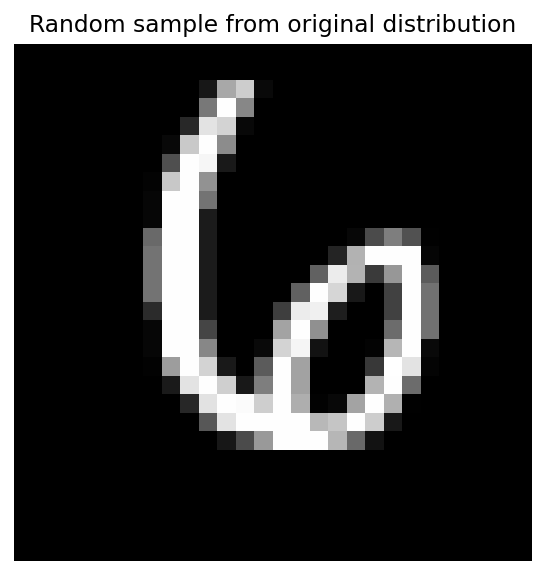

In [ ]:
fig1 = plt.gcf()
plt.imshow(random_image, cmap='gray')
plt.axis('off')
plt.title('Random sample from original distribution')
fig1.savefig('/content/Images/walk_orig_sample.png')

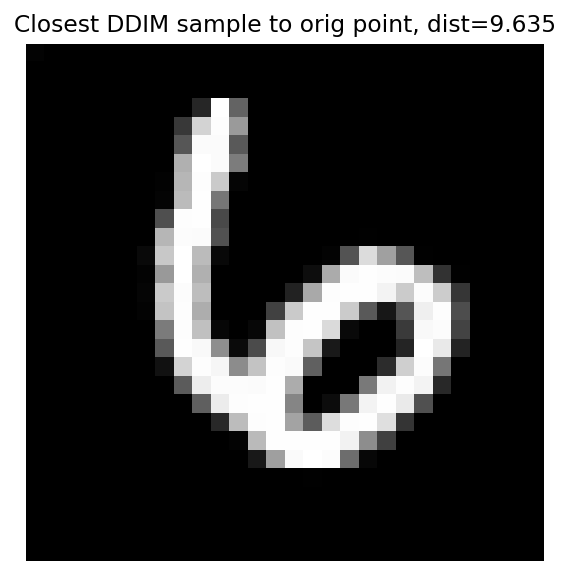

In [ ]:
fig1 = plt.gcf()
plt.imshow(ddim_fake_imgs[closest_ddim_idx].reshape(28, 28), cmap='gray')
plt.axis('off')
plt.title(f'Closest DDIM sample to orig point, dist={ddim_distances_to_orig[closest_ddim_idx]:.3f}')
fig1.savefig('/content/Images/walk_ddim_sample.png')

### Считаем расстояния внутри своих датасетов

In [ ]:
orig_distances = euclidean_distances(orig_embd[None, ...], np.delete(orig_embds, random_idx, axis=0))
orig_distances = orig_distances.squeeze()
orig_distances.shape

(41999,)

In [ ]:
ddim_distances = euclidean_distances(ddim_embds[closest_ddim_idx][None, ...], np.delete(ddim_embds, closest_ddim_idx, axis=0))
ddim_distances = ddim_distances.squeeze()
ddim_distances.shape

(41999,)

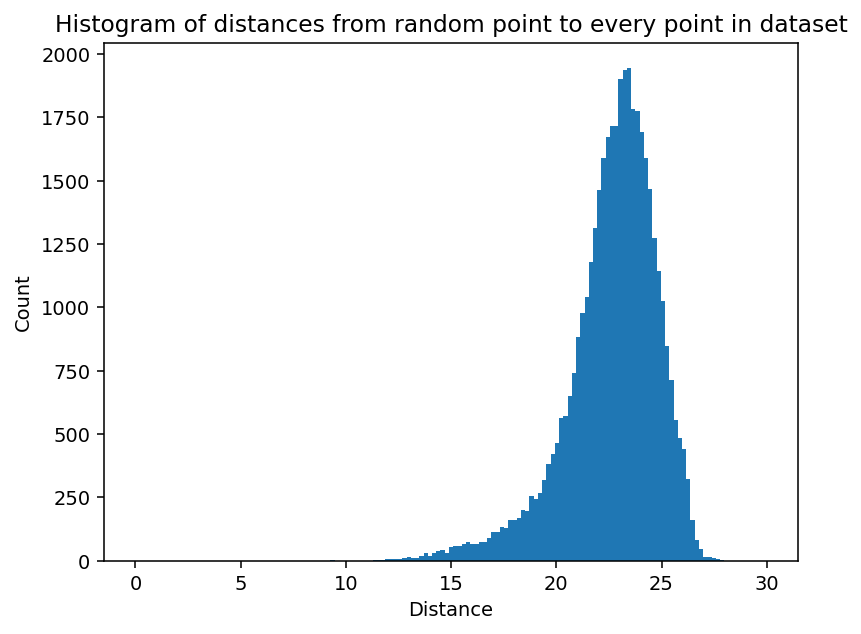

In [ ]:
fig1 = plt.gcf()
plt.hist(orig_distances, bins=np.linspace(0, 30, 150))
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Histogram of distances from random point to every point in dataset')
fig1.savefig('/content/Images/dist_hist_orig_full.png')

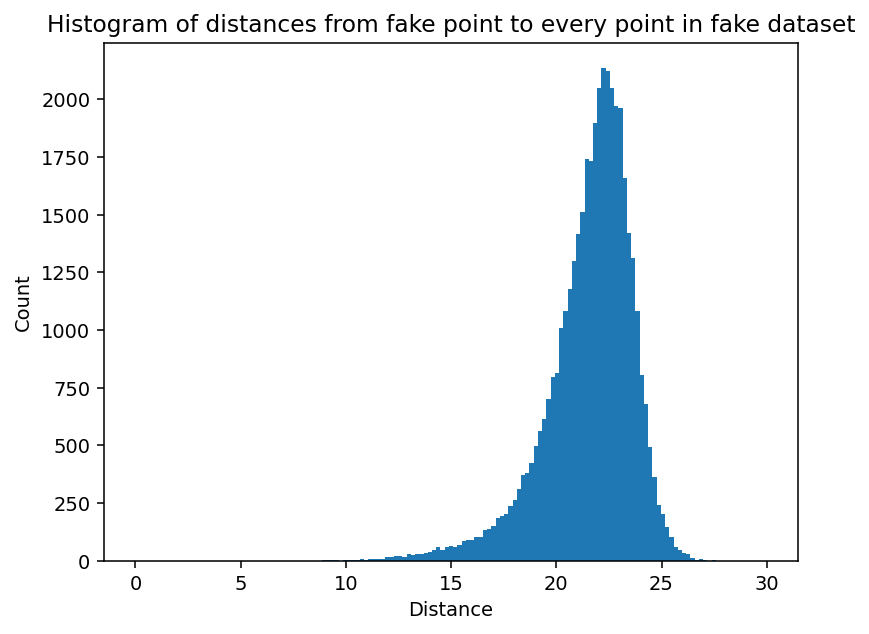

In [ ]:
fig1 = plt.gcf()
plt.hist(ddim_distances, bins=np.linspace(0, 30, 150))
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Histogram of distances from fake point to every point in fake dataset')
fig1.savefig('/content/Images/dist_hist_ddim_full.png')

In [ ]:
head_orig_distances = np.sort(orig_distances)[:1000]
head_ddim_distances = np.sort(ddim_distances)[:1000]

In [ ]:
head_orig_distances[:10]

array([ 9.451831 , 11.455759 , 11.628961 , 11.821031 , 11.852671 ,
       11.886592 , 11.9258585, 11.950504 , 11.965945 , 11.980899 ],
      dtype=float32)

In [ ]:
head_ddim_distances[:10]

array([ 8.908008 ,  9.13826  ,  9.451516 ,  9.483757 ,  9.603671 ,
        9.968459 , 10.144126 , 10.3269205, 10.362259 , 10.487696 ],
      dtype=float32)

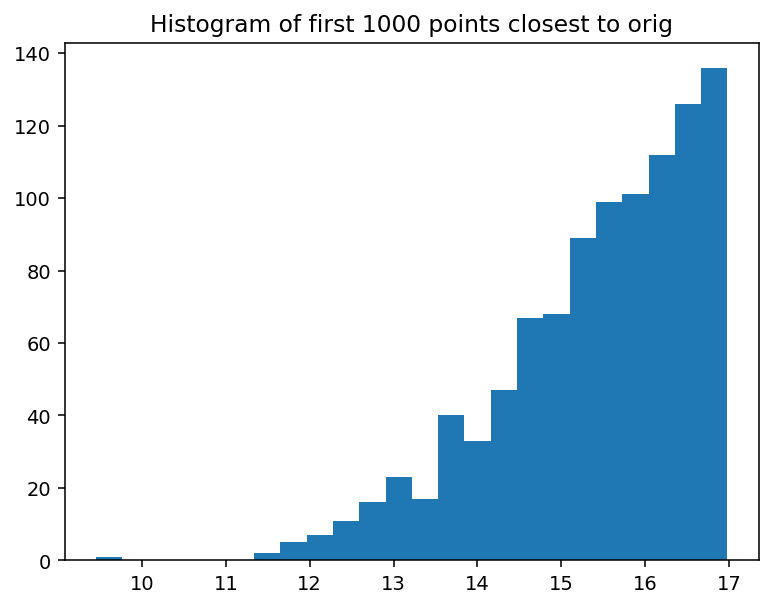

In [ ]:
fig1 = plt.gcf()
Y_orig, bins_orig, _ = plt.hist(head_orig_distances, bins=np.linspace(head_orig_distances[0], head_orig_distances[-1], 25))
plt.title('Histogram of first 1000 points closest to orig')
fig1.savefig('/content/Images/dist_hist_orig_first.png')

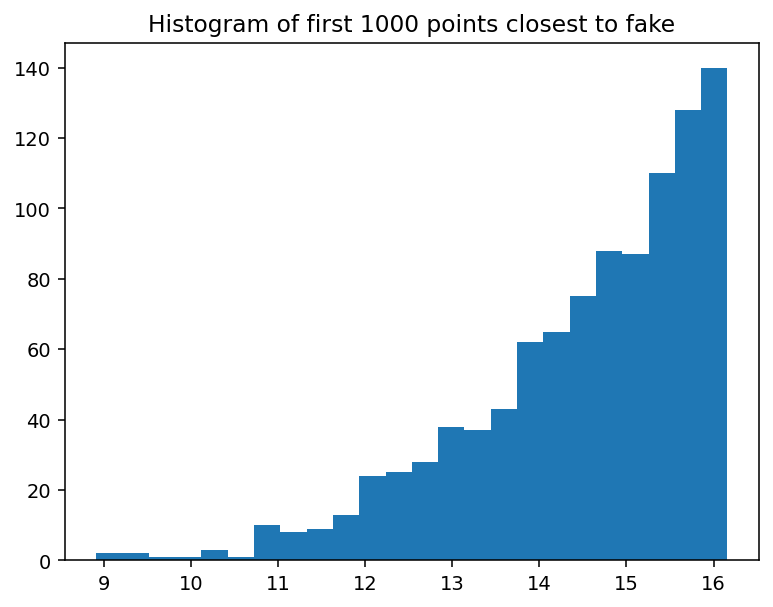

In [ ]:
fig1 = plt.gcf()
Y_fake, bins_fake, _ = plt.hist(head_ddim_distances, bins=np.linspace(head_ddim_distances[0], head_ddim_distances[-1], 25))
plt.title('Histogram of first 1000 points closest to fake')
fig1.savefig('/content/Images/dist_hist_ddim_first.png')

In [ ]:
X_orig = np.array([0.5 * (bins_orig[i] + bins_orig[i+1]) for i in range(len(bins_orig) - 1)])
X_fake = np.array([0.5 * (bins_fake[i] + bins_fake[i+1]) for i in range(len(bins_fake) - 1)])

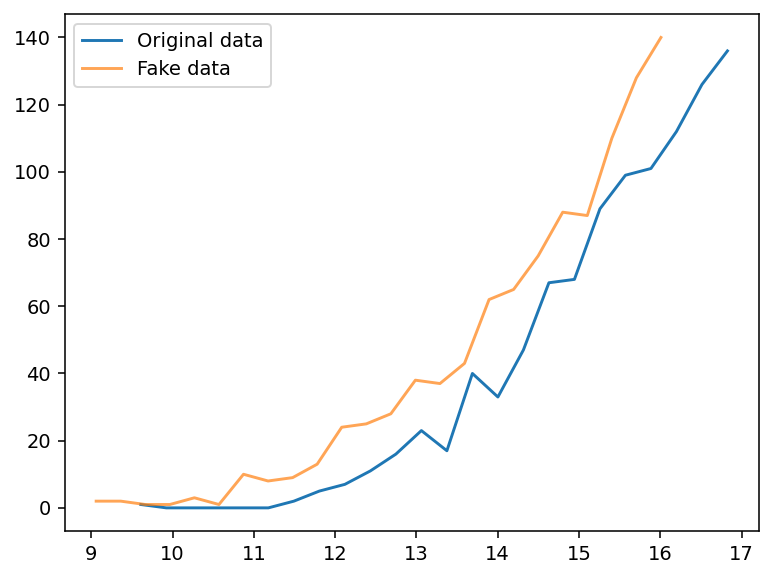

In [ ]:
plt.plot(X_orig, Y_orig, label='Original data')
plt.plot(X_fake, Y_fake, label='Fake data', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
def model(x, a, b, c):
    return a * np.power(x, b) + c

def fit_curve_and_plot(model_func, X, Y, label, plot_name):
    p0 = (1.0, 0.1, 0.0)
    params, cov = curve_fit(model_func, X, Y, p0=p0, maxfev=10000)

    xg = np.linspace(X.min(), X.max(), 1000)
    yg = model(xg, *params)

    fig1 = plt.gcf()
    plt.scatter(X, Y, s=12, label=label)
    plt.plot(xg, yg, linewidth=2, label=f'fit, b={params[1]:.3f}', c='orange')
    plt.xlabel('Distance')
    plt.ylabel('Count')
    plt.legend()
    fig1.savefig('/content/Images/' + plot_name)

    return params

In [ ]:
def plot_errors(model_func, X, Y, params):
    Y_pred = model_func(X, *params)

    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    print(f'RMSE: {rmse}')

    residuals = np.abs(Y - Y_pred)

    plt.figure()
    plt.plot(X, residuals)
    plt.axhline(0)
    plt.title("Residuals ($Y - Y_{pred}$)")
    plt.xlabel("X")
    plt.ylabel("Error")
    plt.show()

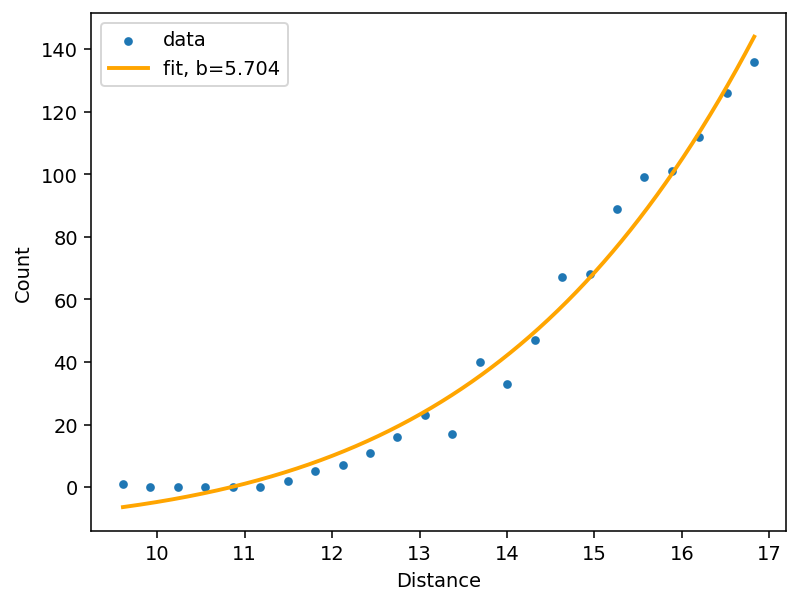

In [ ]:
params = fit_curve_and_plot(model, X_orig, Y_orig, label='data', plot_name='dist_fit_orig.png')

In [ ]:
params

array([ 1.59360717e-05,  5.70368778e+00, -1.27950595e+01])

RMSE: 5.991406413141068


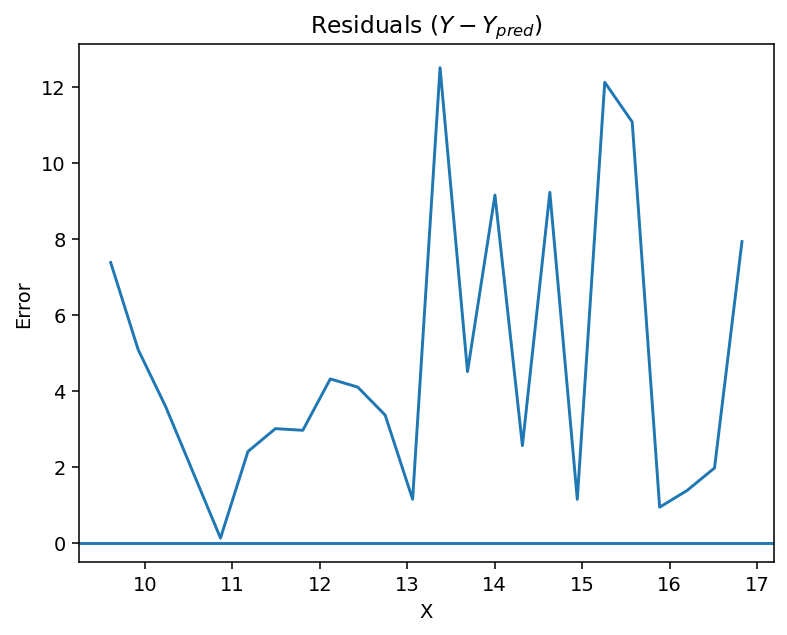

In [ ]:
plot_errors(model, X_orig, Y_orig, params)

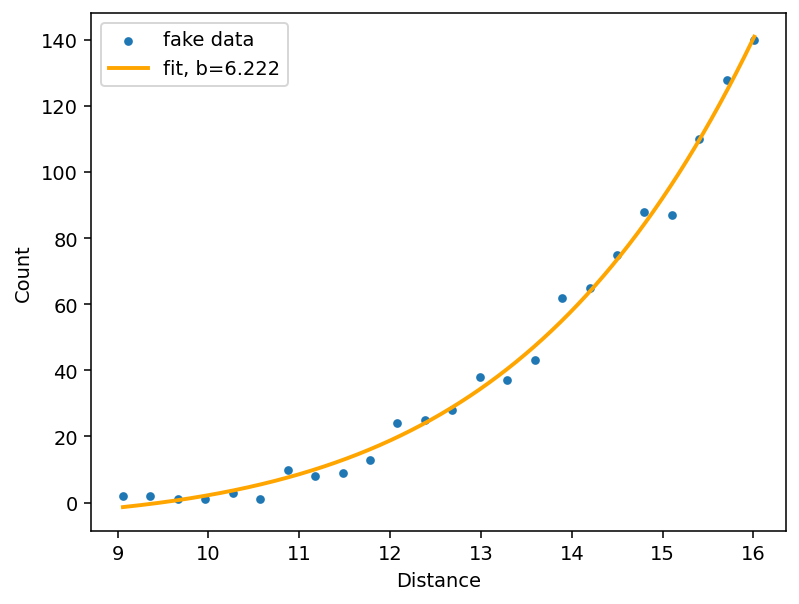

In [ ]:
params = fit_curve_and_plot(model, X_fake, Y_fake, label='fake data', plot_name='dist_fit_ddim.png')

In [ ]:
params

array([ 4.71035634e-06,  6.22170569e+00, -5.62016734e+00])

RMSE: 3.5493985427506525


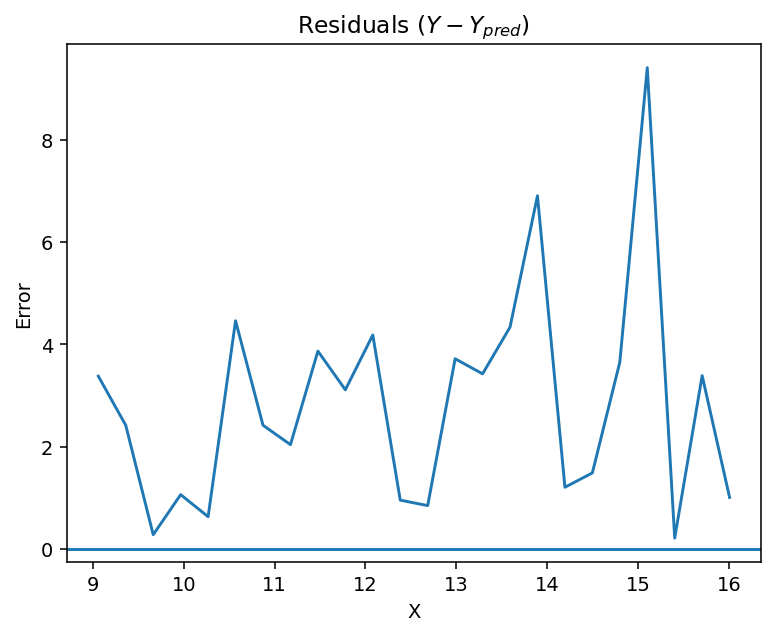

In [ ]:
plot_errors(model, X_fake, Y_fake, params)

### Считаем расстояния внутри реального датасета

In [ ]:
ddim_distances_to_real = euclidean_distances(ddim_embds[closest_ddim_idx][None, ...], orig_embds)
ddim_distances_to_real = ddim_distances_to_real.squeeze()
ddim_distances_to_real.shape

(42000,)

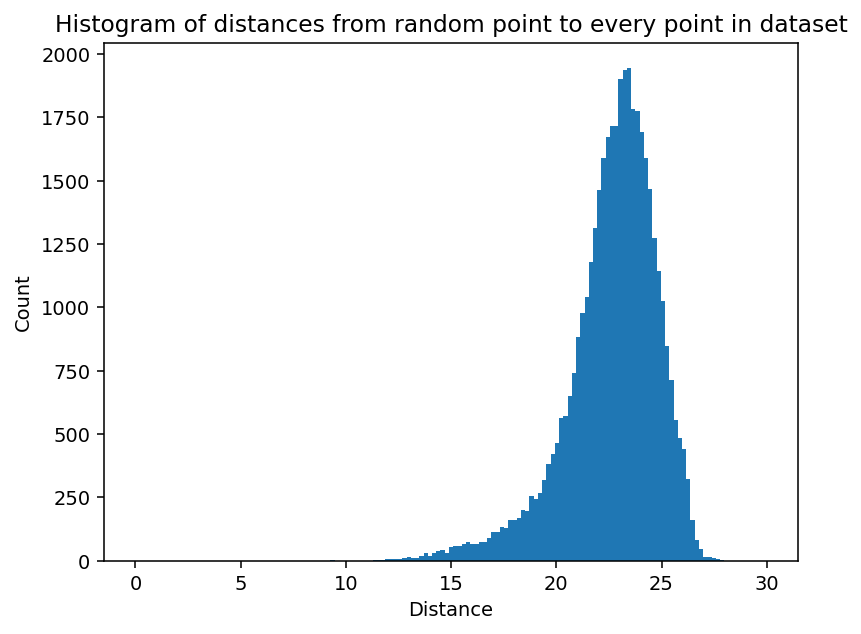

In [ ]:
plt.hist(orig_distances, bins=np.linspace(0, 30, 150))
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Histogram of distances from random point to every point in dataset')
plt.show()

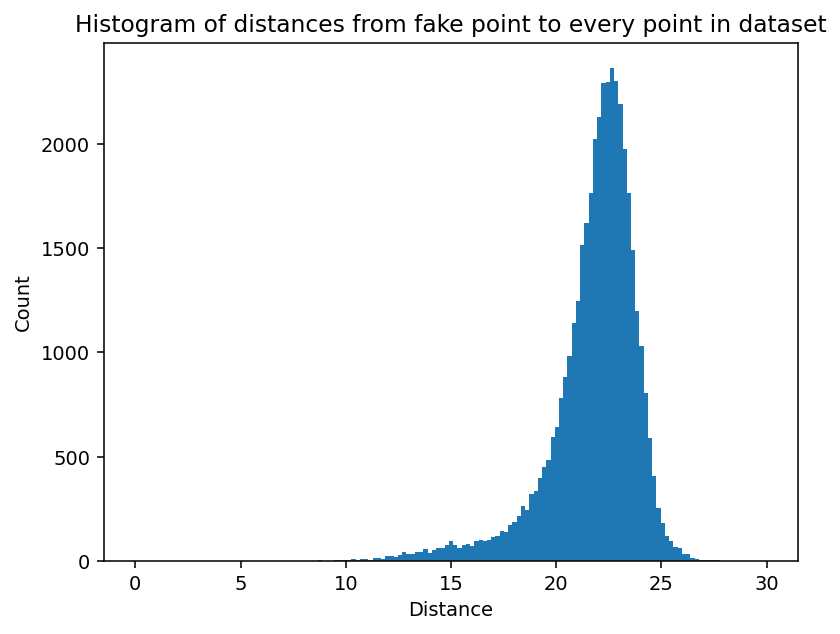

In [ ]:
plt.hist(ddim_distances_to_real, bins=np.linspace(0, 30, 150))
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Histogram of distances from fake point to every point in dataset')
plt.show()

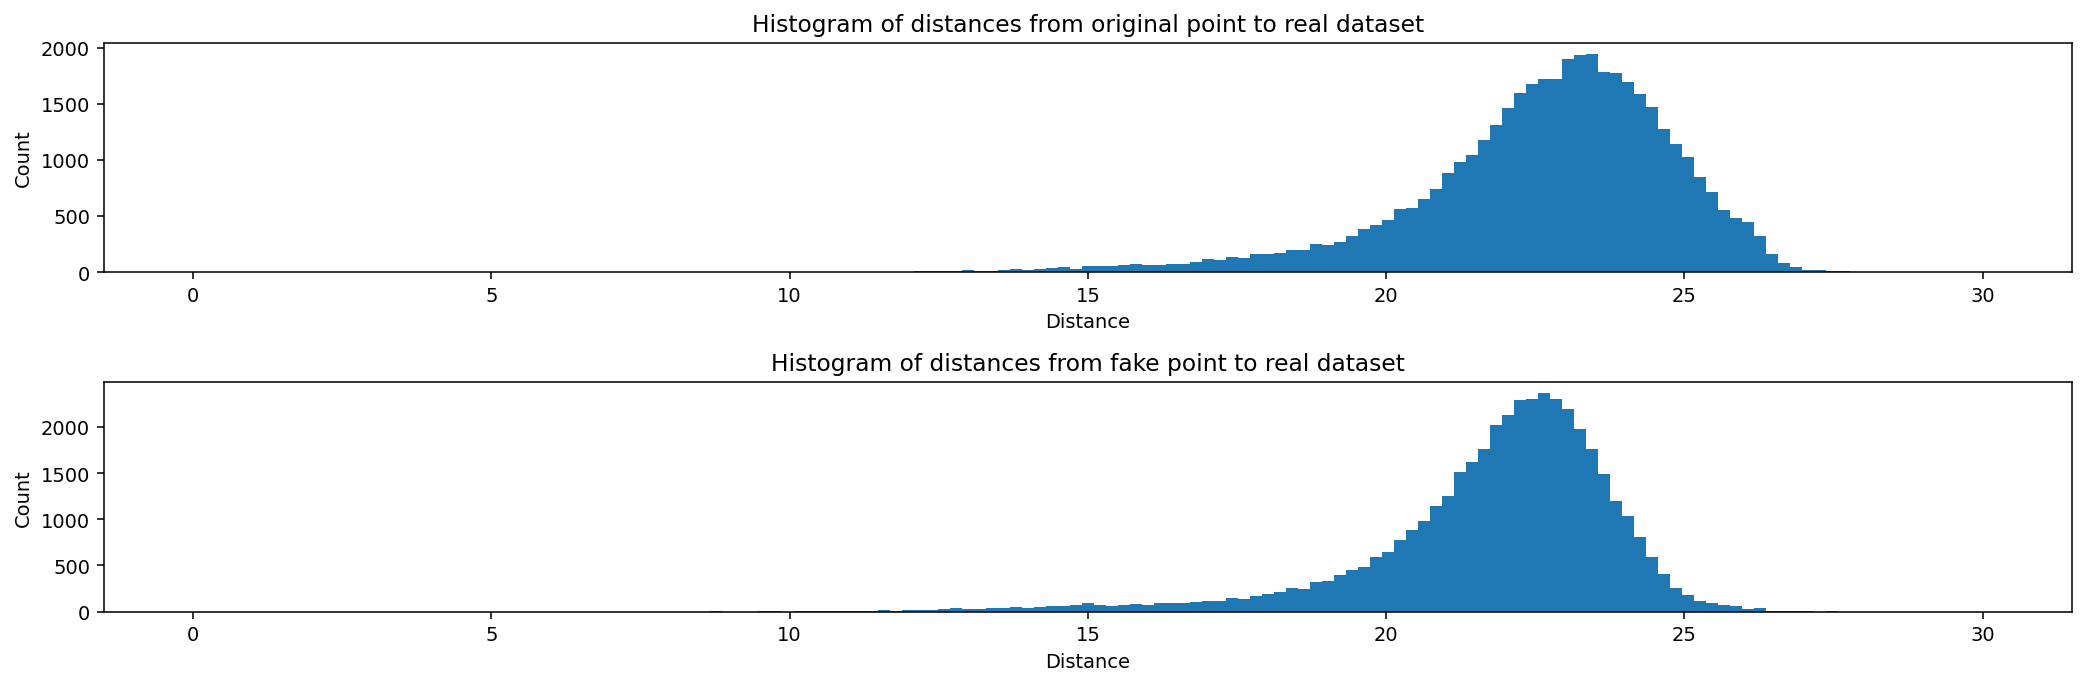

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5))

axes[0].hist(orig_distances, bins=np.linspace(0, 30, 150))
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram of distances from original point to real dataset')

axes[1].hist(ddim_distances_to_real, bins=np.linspace(0, 30, 150))
axes[1].set_xlabel('Distance')
axes[1].set_ylabel('Count')
axes[1].set_title('Histogram of distances from fake point to real dataset')

plt.tight_layout()
plt.show()

In [ ]:
head_ddim_distances_to_real = np.sort(ddim_distances_to_real)[:1000]

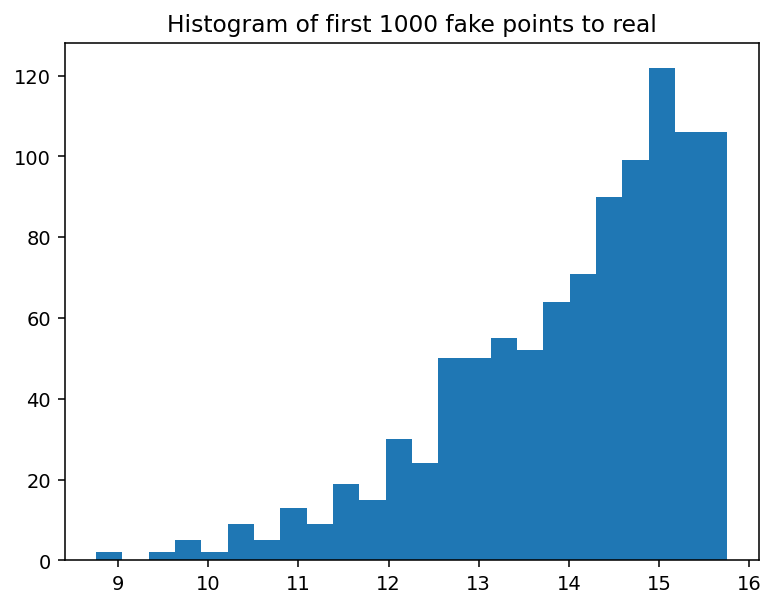

In [ ]:
Y_fake_to_real, bins_fake_to_real, _ = plt.hist(head_ddim_distances_to_real, bins=np.linspace(head_ddim_distances_to_real[0], head_ddim_distances_to_real[-1], 25))
plt.title('Histogram of first 1000 fake points to real')
plt.show()

In [ ]:
X_fake_to_real = np.array([0.5 * (bins_fake_to_real[i] + bins_fake_to_real[i+1]) for i in range(len(bins_fake_to_real) - 1)])

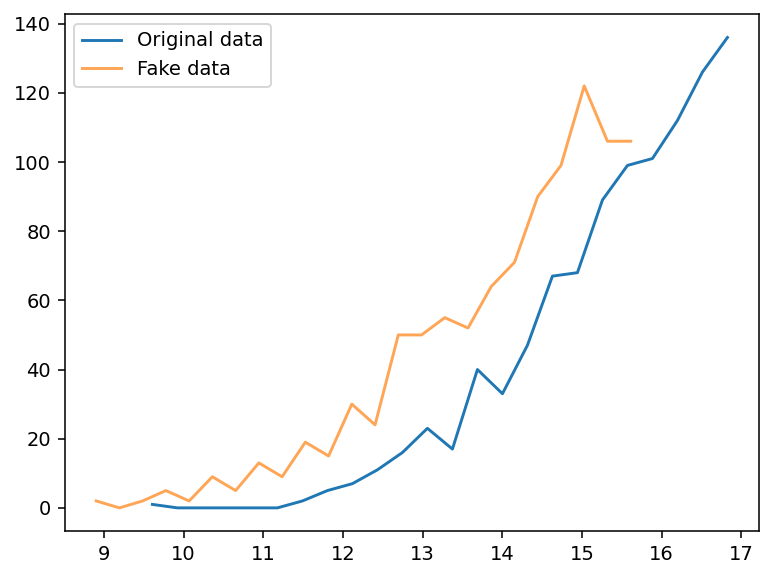

In [ ]:
plt.plot(X_orig, Y_orig, label='Original data')
plt.plot(X_fake_to_real, Y_fake_to_real, label='Fake data', alpha=0.7)
plt.legend()
plt.show()

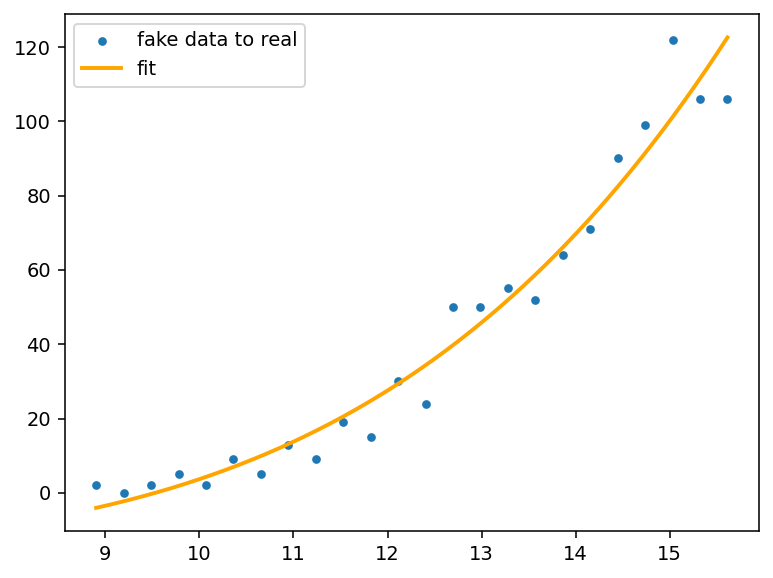

In [ ]:
params = fit_curve_and_plot(model, X_fake_to_real, Y_fake_to_real, label='fake data to real')

In [ ]:
params

array([ 7.19321798e-04,  4.42685011e+00, -1.55461769e+01])

RMSE: 7.640724792345541


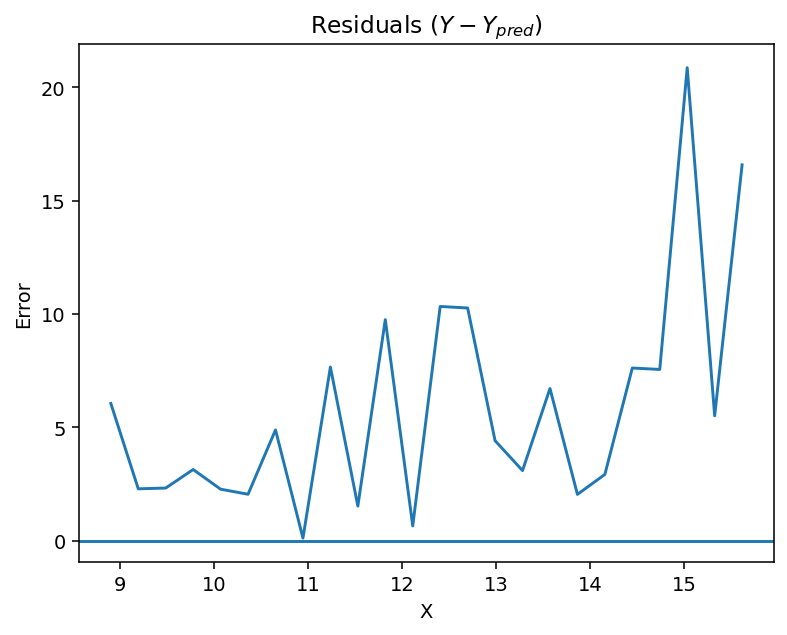

In [ ]:
plot_errors(model, X_fake_to_real, Y_fake_to_real, params)